# Práctica: Clasificación en el Juego del Ultimátum con XAI y Blockchain

En esta práctica trabajarás con datos fisiológicos (frecuencia cardíaca, conductancia galvánica y EEG) capturados durante el Juego del Ultimátum. Primero correrás un ejemplo ya resuelto que muestra el pipeline completo: entrenamiento de un modelo Random Forest, explicabilidad con SHAP y registro en blockchain. Después, con un segundo dataset de features fisiológicas corregidas por baseline, elegirás tus propias features, entrenarás el modelo, analizarás qué señales son más relevantes para predecir si un participante acepta o rechaza una oferta, y compararás tus resultados con el ejemplo

Este notebook tiene dos partes:

- **Parte 1 (ejemplo)**: Modelo V1 con features crudas de ejemplo
- **Parte 2**: Modelo 2 con features fisiológicas de detección de enojo —
  aquí tú eliges features, interpretas SHAP y escribes conclusiones.
- **Parte 3**: Comparación de ambos modelos.

### Configuración

| Elemento | Valor |
|----------|------|
| Modelo | Random Forest (mismos hiperparámetros) |
| Validación | LOSO, 4 folds |
| XAI | SHAP TreeExplainer |


In [1]:
!pip install -q web3 shap eth_account -q


In [2]:
# Dependencias para modelos GBM
!pip install -q lightgbm catboost xgboost


In [51]:
!pip install LogisticRegression -q

---
## 0. Setup


In [3]:
import hashlib, json, os, sys, io, warnings, pickle, platform
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report,
)

import shap

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

# --- Chain logger (blockchain) ---
from xai_chain_logger import chain_logger, Stage, get_chain_logger

# --- Configuración fija para todos ---
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

FEATURES_DIR = Path(".")

# --- Utilidades ---
def sha256_bytes(b: bytes) -> str:
    return hashlib.sha256(b).hexdigest()

def sha256_text(s: str) -> str:
    return sha256_bytes(s.encode('utf-8'))

def json_stable(obj) -> str:
    return json.dumps(obj, sort_keys=True, ensure_ascii=False, separators=(',',':'), default=str)

def df_hash(df):
    buf = io.StringIO()
    df.to_csv(buf, index=False, float_format='%.10g')
    return sha256_bytes(buf.getvalue().encode('utf-8'))

def safe_register(stage, payload):
    """Registra en blockchain. Si no hay gas, guarda el payload localmente."""
    try:
        ok, tx_hash, record = chain_logger.register(stage=stage, payload=payload)
        print(f"  [ON-CHAIN] OK | TX: {tx_hash}")
        return tx_hash
    except Exception as e:
        msg = str(e)
        if 'insufficient funds' in msg:
            print(f"  [ON-CHAIN] SKIP — Sin gas en Sepolia")
        else:
            print(f"  [ON-CHAIN] ERROR: {msg[:120]}")
        pending = {"stage": stage.value, "payload": payload}
        path = OUTPUT_DIR / f"pending_{stage.value}.json"
        with open(path, 'w') as f:
            json.dump(pending, f, indent=2, default=str)
        print(f"  [OFF-CHAIN] Guardado en {path}")
        return None

ALL_TX = {}

print(f"Chain logger: {'OK' if chain_logger else 'NO DISPONIBLE'}")


Chain logger: OK


In [4]:
# Imports para modelos GBM, busqueda de hiperparametros y seleccion de features
import copy, zipfile
from lightgbm import LGBMClassifier

try:
    from catboost import CatBoostClassifier
    _catboost_ok = True
except ImportError:
    _catboost_ok = False
    print('CatBoost no instalado — se omite del benchmark')

try:
    from xgboost import XGBClassifier
    _xgb_ok = True
except ImportError:
    _xgb_ok = False
    print('XGBoost no instalado — se omite del benchmark')

from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform

print(f'LightGBM : OK')
print(f'CatBoost : {"OK" if _catboost_ok else "no instalado"}')
print(f'XGBoost  : {"OK" if _xgb_ok else "no instalado"}')


LightGBM : OK
CatBoost : OK
XGBoost  : OK


---
---
# PARTE 1 (Ejemplo) — Dataset V1: Features Crudas


In [5]:
DATASET_VERSION = "V1_raw"
OUTPUT_DIR = Path("output_v1_raw")
OUTPUT_DIR.mkdir(exist_ok=True)
ALL_TX = {}

---
## 1. Carga del dataset V1

In [6]:
df_full = pd.read_csv(Path("dataset_A_naive.csv"))

CLEAN_PARTICIPANTS = ["P001", "P003", "P004", "P005"]

df = df_full[
    (df_full["participant_id"].isin(CLEAN_PARTICIPANTS)) &
    (df_full["decision"].isin(["accept", "reject"]))
].copy()
df["label"] = (df["decision"] == "accept").astype(int)

print(f"Participantes: {sorted(df['participant_id'].unique().tolist())}")
print(f"Trials: {len(df)} (accept={df['label'].sum()}, reject={int((1-df['label']).sum())})")
print(f"\nColumnas disponibles ({len(df.columns)}):")
print(df.columns.tolist())
print()
df.describe().T


Participantes: ['P001', 'P003', 'P004', 'P005']
Trials: 95 (accept=29, reject=66)

Columnas disponibles (25):
['participant_id', 'trial_number', 'offer_amount', 'offer_category', 'decision', 'decision_time_s', 'mean_hr', 'hr_std', 'mean_rr_ms', 'rmssd', 'sdnn', 'pnn50', 'mean_gsr', 'max_gsr', 'gsr_std', 'ecg_amplitude_range', 'ecg_std', 'mean_eeg_tp9', 'mean_eeg_af7', 'mean_eeg_af8', 'mean_eeg_tp10', 'gsr_reliable', 'hr_reliable', 'eeg_available', 'label']



,count,mean,std,min,25%,50%,75%,max
trial_number,95.0,12.621053,6.893072,1.000000,7.000000,13.000000,18.500000,24.000000
offer_amount,95.0,2.568421,1.407825,0.500000,1.500000,3.000000,3.500000,5.000000
decision_time_s,95.0,0.000053,0.006612,-0.012500,-0.005500,0.000000,0.005000,0.013000
mean_hr,95.0,88.373253,24.784108,37.669643,70.784722,77.818182,108.627976,136.384615
hr_std,95.0,4.341969,2.485515,0.868115,2.225410,3.876338,5.865343,13.578086
mean_rr_ms,95.0,737.025499,207.281487,440.346154,571.270000,789.730769,850.564103,1655.076190
rmssd,94.0,41.503234,36.089740,4.538722,23.589935,32.844256,57.212112,215.830518
sdnn,94.0,52.341089,45.756307,4.591659,29.248012,42.265560,66.415867,308.004610
pnn50,94.0,16.936596,17.537955,0.000000,0.000000,11.538462,27.355072,75.000000
mean_gsr,95.0,21310.505708,5716.382597,12024.712857,15616.915833,22395.600769,26992.485144,28458.650000


### Features seleccionadas para este ejemplo

En este ejemplo usamos **todas las features V1** disponibles.
En la parte 2 tú elegirás cuáles usar.


In [7]:
FEATURE_COLS = [
    "offer_amount", "decision_time_s",
    "mean_hr", "hr_std",
    "rmssd", "sdnn", "pnn50",
    "mean_gsr", "max_gsr", "gsr_std",
    "mean_eeg_af7", "mean_eeg_af8",
]

print(f"Features seleccionadas ({len(FEATURE_COLS)}): {FEATURE_COLS}")

# Missingness check
print(f"\nMissingness:")
for col in FEATURE_COLS:
    miss = df[col].isna().sum()
    pct = miss / len(df) * 100
    print(f"  {col:20s}: {miss:3d}/{len(df)} ({pct:.1f}%)")


Features seleccionadas (12): ['offer_amount', 'decision_time_s', 'mean_hr', 'hr_std', 'rmssd', 'sdnn', 'pnn50', 'mean_gsr', 'max_gsr', 'gsr_std', 'mean_eeg_af7', 'mean_eeg_af8']

Missingness:
  offer_amount        :   0/95 (0.0%)
  decision_time_s     :   0/95 (0.0%)
  mean_hr             :   0/95 (0.0%)
  hr_std              :   0/95 (0.0%)
  rmssd               :   1/95 (1.1%)
  sdnn                :   1/95 (1.1%)
  pnn50               :   1/95 (1.1%)
  mean_gsr            :   0/95 (0.0%)
  max_gsr             :   0/95 (0.0%)
  gsr_std             :   0/95 (0.0%)
  mean_eeg_af7        :   0/95 (0.0%)
  mean_eeg_af8        :   0/95 (0.0%)


In [8]:
# EDA: valores promedio por clase para tus features
print("Accept vs Reject — valores crudos:")
print("=" * 75)
for col in FEATURE_COLS:
    acc = df[df['decision']=='accept'][col].mean()
    rej = df[df['decision']=='reject'][col].mean()
    delta = acc - rej
    print(f"  {col:20s}: accept={acc:10.2f}  reject={rej:10.2f}  diff={delta:+.2f}")


Accept vs Reject — valores crudos:
  offer_amount        : accept=      4.24  reject=      1.83  diff=+2.41
  decision_time_s     : accept=      0.00  reject=     -0.00  diff=+0.00
  mean_hr             : accept=     92.93  reject=     86.37  diff=+6.56
  hr_std              : accept=      3.65  reject=      4.65  diff=-1.00
  rmssd               : accept=     33.42  reject=     44.93  diff=-11.51
  sdnn                : accept=     40.80  reject=     57.24  diff=-16.44
  pnn50               : accept=     13.95  reject=     18.20  diff=-4.25
  mean_gsr            : accept=  21706.46  reject=  21136.52  diff=+569.94
  max_gsr             : accept=  22349.99  reject=  22018.84  diff=+331.15
  gsr_std             : accept=    518.91  reject=    748.97  diff=-230.05
  mean_eeg_af7        : accept=    730.61  reject=    729.44  diff=+1.17
  mean_eeg_af8        : accept=    727.28  reject=    729.35  diff=-2.07


In [9]:
# Guardar dataset limpio
clean_path = OUTPUT_DIR / "dataset_v1_clean.csv"
df.to_csv(clean_path, index=False)
dataset_sha256 = df_hash(df)
print(f"Dataset SHA-256: {dataset_sha256}")

Dataset SHA-256: ffbb7a9efc417f1ca8b97a428419bf3c5151b54916e5524df33647217a18eee6


### >>> REGISTRO ON-CHAIN: DATASET_INGEST <<<

> Corre esta celda **solo cuando hayas terminado de explorar** el dataset.
> Registra el hash del CSV + metadata en Ethereum Sepolia.

In [10]:
ingest_payload = {
    "dataset_version": DATASET_VERSION,
    "dataset_sha256": dataset_sha256,
    "n_rows": len(df),
    "n_features": len(FEATURE_COLS),
    "features": FEATURE_COLS,
    "participants": len(CLEAN_PARTICIPANTS),
    "class_balance": {"accept": int(df['label'].sum()), "reject": int((1-df['label']).sum())},
}

print("Payload DATASET_INGEST:")
print(json_stable(ingest_payload))
print()
ALL_TX["dataset_ingest"] = safe_register(Stage.DATASET_INGEST, ingest_payload)

Payload DATASET_INGEST:
{"class_balance":{"accept":29,"reject":66},"dataset_sha256":"ffbb7a9efc417f1ca8b97a428419bf3c5151b54916e5524df33647217a18eee6","dataset_version":"V1_raw","features":["offer_amount","decision_time_s","mean_hr","hr_std","rmssd","sdnn","pnn50","mean_gsr","max_gsr","gsr_std","mean_eeg_af7","mean_eeg_af8"],"n_features":12,"n_rows":95,"participants":4}

[web3] Sent tx: 3104568f7096798a8a193973262023430ede03a4183c7c14f7f67349d8db3483
  [ON-CHAIN] OK | TX: 3104568f7096798a8a193973262023430ede03a4183c7c14f7f67349d8db3483


---
## 2. Preprocessing

Pipeline fijo: imputación con mediana (para los NaN de sensores) + estandarización z-score.
Todos los equipos usan el mismo pipeline para que los resultados sean comparables.

In [11]:
X_raw = df[FEATURE_COLS].values
y = df["label"].values
groups = df["participant_id"].values
feature_names = FEATURE_COLS

preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
preprocessor.fit(X_raw)
X = preprocessor.transform(X_raw)

scaler = preprocessor.named_steps["scaler"]
imputer = preprocessor.named_steps["imputer"]

scaler_state = {"mean": scaler.mean_.tolist(), "scale": scaler.scale_.tolist()}
X_sha256 = sha256_bytes(X.tobytes())

print(f"X shape: {X.shape}")
print(f"X SHA-256: {X_sha256}")

X shape: (95, 12)
X SHA-256: 0297e499c4f12e684f884528fc1ae2c372a4c29daf7085d3a9df33820f9a227d


### >>> REGISTRO ON-CHAIN: PREPROCESSING <<<

In [12]:
preproc_payload = {
    "pipeline": "SimpleImputer(median)+StandardScaler",
    "scaler_sha256": sha256_text(json_stable(scaler_state)),
    "X_sha256": X_sha256,
    "n_samples": len(X),
    "n_features": X.shape[1],
}
print("Payload PREPROCESSING:")
print(json_stable(preproc_payload))
print()
ALL_TX["preprocessing"] = safe_register(Stage.PREPROCESSING, preproc_payload)

Payload PREPROCESSING:
{"X_sha256":"0297e499c4f12e684f884528fc1ae2c372a4c29daf7085d3a9df33820f9a227d","n_features":12,"n_samples":95,"pipeline":"SimpleImputer(median)+StandardScaler","scaler_sha256":"dc8a784ade8ab29db364f6c1499b427393e24b4a79d1da35a83875fce7ba143a"}

[web3] Sent tx: 3bd90f1f5571b2b53a229d22c9d42e2e13b36d75b0a0a4211b385bb7ef5793c7
  [ON-CHAIN] OK | TX: 3bd90f1f5571b2b53a229d22c9d42e2e13b36d75b0a0a4211b385bb7ef5793c7


---
## 3. Entrenamiento — Random Forest + LOSO

El modelo y los hiperparámetros están fijos para todos. Lo que cambia son las features
que elegiste arriba.

**Ejecuta las siguientes celdas** para entrenar con tus features y ver los resultados.


In [13]:
# --- Hiperparámetros ---
HYPERPARAMS = {
    "n_estimators": 200,
    "max_depth": 4,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "random_state": RANDOM_SEED,
    "n_jobs": -1,
}

logo = LeaveOneGroupOut()
rf = RandomForestClassifier(**HYPERPARAMS)

y_pred = cross_val_predict(rf, X, y, cv=logo, groups=groups)
y_proba = cross_val_predict(rf, X, y, cv=LeaveOneGroupOut(), groups=groups,
                             method="predict_proba")[:, 1]

try:
    auc = float(roc_auc_score(y, y_proba))
except:
    auc = None

metrics = {
    "accuracy": float(accuracy_score(y, y_pred)),
    "precision": float(precision_score(y, y_pred, zero_division=0)),
    "recall": float(recall_score(y, y_pred, zero_division=0)),
    "f1_macro": float(f1_score(y, y_pred, average="macro")),
    "roc_auc": auc,
}

print("METRICAS LOSO — Dataset V1 (Raw)")
print("=" * 50)
for k, v in metrics.items():
    print(f"  {k:15s}: {v:.4f}" if v else f"  {k:15s}: N/A")

print(f"\n{classification_report(y, y_pred, target_names=['reject','accept'])}")

# Por participante
print("Por participante:")
for pid in CLEAN_PARTICIPANTS:
    mask = groups == pid
    acc = accuracy_score(y[mask], y_pred[mask])
    print(f"  {pid}: acc={acc:.3f} (n={mask.sum()})")

METRICAS LOSO — Dataset V1 (Raw)
  accuracy       : 0.9474
  precision      : 1.0000
  recall         : 0.8276
  f1_macro       : 0.9346
  roc_auc        : 0.9687

              precision    recall  f1-score   support

      reject       0.93      1.00      0.96        66
      accept       1.00      0.83      0.91        29

    accuracy                           0.95        95
   macro avg       0.96      0.91      0.93        95
weighted avg       0.95      0.95      0.95        95

Por participante:
  P001: acc=1.000 (n=24)
  P003: acc=0.833 (n=24)
  P004: acc=0.957 (n=23)
  P005: acc=1.000 (n=24)


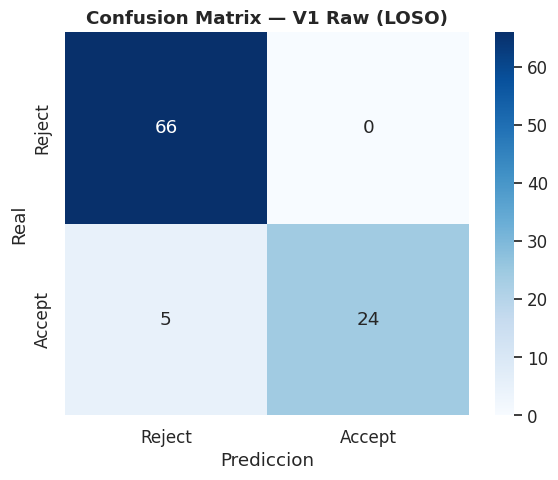

In [14]:
# Confusion matrix
cm = confusion_matrix(y, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Reject','Accept'], yticklabels=['Reject','Accept'], ax=ax)
ax.set_xlabel('Prediccion'); ax.set_ylabel('Real')
ax.set_title(f'Confusion Matrix — V1 Raw (LOSO)', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix_v1.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Modelo final (entrenado en todos los datos, para SHAP)
model_final = RandomForestClassifier(**HYPERPARAMS)
model_final.fit(X, y)

bundle = pickle.dumps({"preprocessor": preprocessor, "model": model_final,
                        "features": FEATURE_COLS, "hyperparams": HYPERPARAMS})
bundle_sha256 = sha256_bytes(bundle)
with open(OUTPUT_DIR / "model_v1.pkl", "wb") as f:
    f.write(bundle)
print(f"Bundle SHA-256: {bundle_sha256}")

Bundle SHA-256: 2a6f5437999c069b15181197977a72078e3b3764dca5b9661e1c1500e4f5c0c6


### >>> REGISTRO ON-CHAIN: TRAINING <<<

In [16]:
train_payload = {
    "dataset_version": DATASET_VERSION,
    "model": "RandomForest",
    "hyperparams": HYPERPARAMS,
    "validation": "LOSO",
    "acc": round(metrics["accuracy"], 4),
    "f1": round(metrics["f1_macro"], 4),
    "auc": round(metrics["roc_auc"], 4) if metrics["roc_auc"] else None,
    "bundle_sha256": bundle_sha256,
}
print("Payload TRAINING:")
print(json_stable(train_payload))
print()
ALL_TX["training"] = safe_register(Stage.TRAINING, train_payload)

Payload TRAINING:
{"acc":0.9474,"auc":0.9687,"bundle_sha256":"2a6f5437999c069b15181197977a72078e3b3764dca5b9661e1c1500e4f5c0c6","dataset_version":"V1_raw","f1":0.9346,"hyperparams":{"max_depth":4,"min_samples_leaf":1,"min_samples_split":2,"n_estimators":200,"n_jobs":-1,"random_state":42},"model":"RandomForest","validation":"LOSO"}

[web3] Sent tx: 822a226bf0f9827eab2814137e6946087fe9692847e23ea66f47f2c21541639c
  [ON-CHAIN] OK | TX: 822a226bf0f9827eab2814137e6946087fe9692847e23ea66f47f2c21541639c


---
## 4. SHAP — Explicabilidad

Configuración fija: TreeExplainer con 80 samples de background.

In [17]:
bg_size = min(80, X.shape[0])
bg_idx = np.random.RandomState(RANDOM_SEED).choice(X.shape[0], size=bg_size, replace=False)
background = X[bg_idx]
bg_sha256 = sha256_bytes(background.tobytes())

explainer = shap.TreeExplainer(model_final, data=background, feature_names=feature_names)
explanation = explainer(X)
sv = explanation.values
if sv.ndim == 3:
    sv = sv[:, :, 1]

mean_shap = np.abs(sv).mean(axis=0)
shap_order = np.argsort(mean_shap)[::-1]

print("SHAP Feature Importance — V1 Raw:")
print("=" * 55)
shap_ranking = []
for rank, idx in enumerate(shap_order, 1):
    pct = mean_shap[idx] / mean_shap.sum() * 100
    print(f"  {rank:2d}. {feature_names[idx]:20s} {mean_shap[idx]:.4f} ({pct:.1f}%)")
    shap_ranking.append({"feature": feature_names[idx], "mean_abs_shap": round(float(mean_shap[idx]), 6)})

SHAP Feature Importance — V1 Raw:
   1. offer_amount         0.2107 (61.4%)
   2. sdnn                 0.0190 (5.5%)
   3. hr_std               0.0183 (5.3%)
   4. rmssd                0.0155 (4.5%)
   5. mean_hr              0.0137 (4.0%)
   6. gsr_std              0.0122 (3.5%)
   7. pnn50                0.0118 (3.4%)
   8. decision_time_s      0.0110 (3.2%)
   9. mean_eeg_af8         0.0090 (2.6%)
  10. max_gsr              0.0086 (2.5%)
  11. mean_eeg_af7         0.0070 (2.0%)
  12. mean_gsr             0.0065 (1.9%)


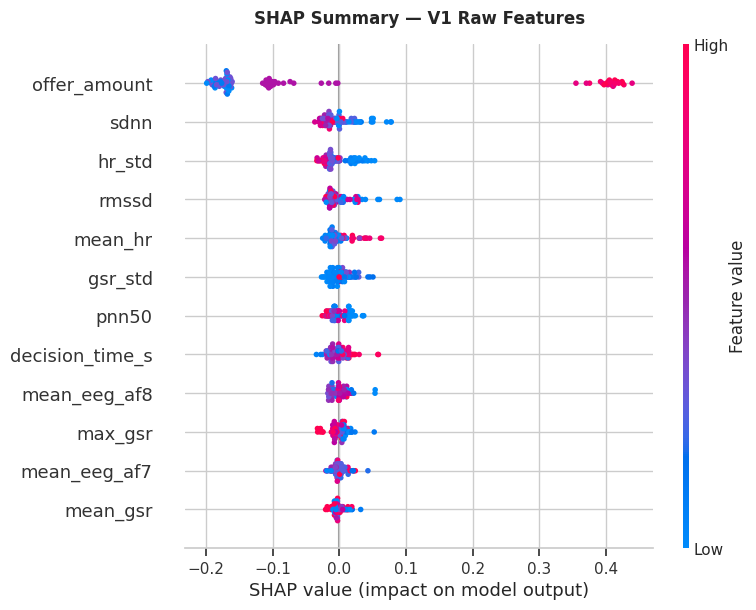

In [18]:
# Summary plot
plt.figure(figsize=(12, 7))
shap.summary_plot(sv, X, feature_names=feature_names, show=False)
plt.title('SHAP Summary — V1 Raw Features', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'shap_summary_v1.png', dpi=150, bbox_inches='tight')
plt.show()

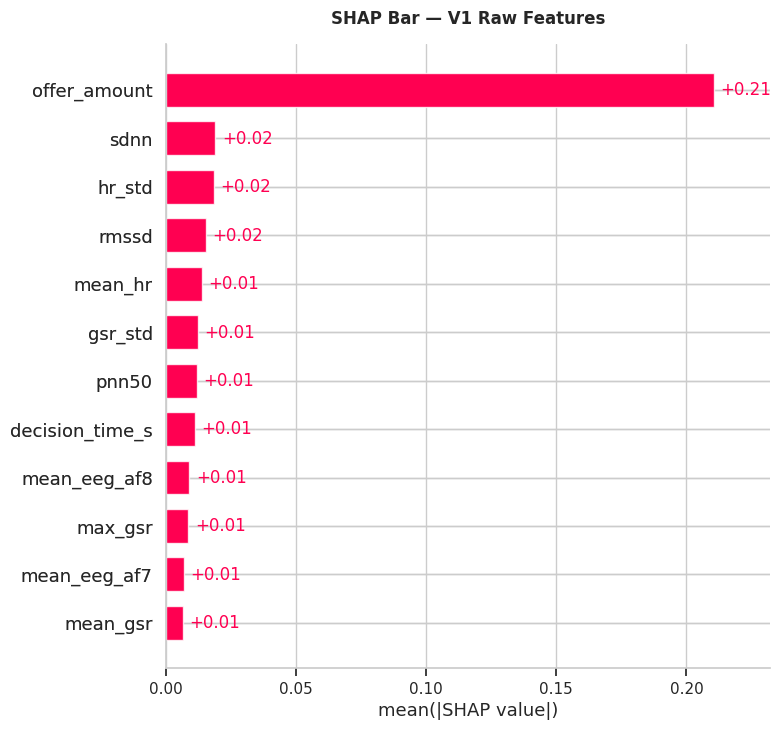

In [19]:
# Bar plot
plt.figure(figsize=(10, 6))
shap.plots.bar(shap.Explanation(values=sv, data=X, feature_names=feature_names),
               max_display=12, show=False)
plt.title('SHAP Bar — V1 Raw Features', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'shap_bar_v1.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretación — SHAP global

En este ejemplo, las features con mayor impacto según SHAP suelen ser:

- **`offer_amount`**: el monto de la oferta es el predictor más fuerte.
- **Features cardíacas** (`mean_hr`, `rmssd`, `sdnn`): capturan el estado autonómico del
  participante, aunque al ser valores absolutos mezclan la línea base con la respuesta.
- **`mean_gsr`**: la conductancia galvánica refleja arousal general, pero sin corrección
  por baseline es difícil separar el estado basal de la reacción al estímulo.

Nota cómo `offer_amount` domina. En la parte 2 verás si los sensores por sí solos pueden predecir.


### >>> REGISTRO ON-CHAIN: EXPLAINABILITY_SETUP <<<

In [20]:
xai_payload = {
    "type": "TreeExplainer",
    "bg_n": bg_size,
    "bg_sha256": bg_sha256,
    "top5_features": [r["feature"] for r in shap_ranking[:5]],
    "top5_shap": [r["mean_abs_shap"] for r in shap_ranking[:5]],
}
print("Payload EXPLAINABILITY_SETUP:")
print(json_stable(xai_payload))
print()
ALL_TX["explainability"] = safe_register(Stage.EXPLAINABILITY_SETUP, xai_payload)

Payload EXPLAINABILITY_SETUP:
{"bg_n":80,"bg_sha256":"f231905f73e5a5c97288e031bb792a15ee3945e73795792836f61c5805aa8143","top5_features":["offer_amount","sdnn","hr_std","rmssd","mean_hr"],"top5_shap":[0.210662,0.019011,0.018347,0.015456,0.013663],"type":"TreeExplainer"}

[web3] Sent tx: cdff3a5f4d2ec714e4daff2024b77503d2b133b92f5a493c5b26f2e054065d9c
  [ON-CHAIN] OK | TX: cdff3a5f4d2ec714e4daff2024b77503d2b133b92f5a493c5b26f2e054065d9c


---
## 5. Waterfall — Casos individuales

Los waterfall plots muestran la contribución de cada feature para un trial específico.
Es la versión "local" de SHAP: en vez del ranking global, ves qué empujó la predicción
de ese caso en particular.



Reject correcto: P001 T02
  Real: reject | Pred: reject
    1. offer_amount        : -0.1699
    2. sdnn                : -0.0213
    3. hr_std              : -0.0204


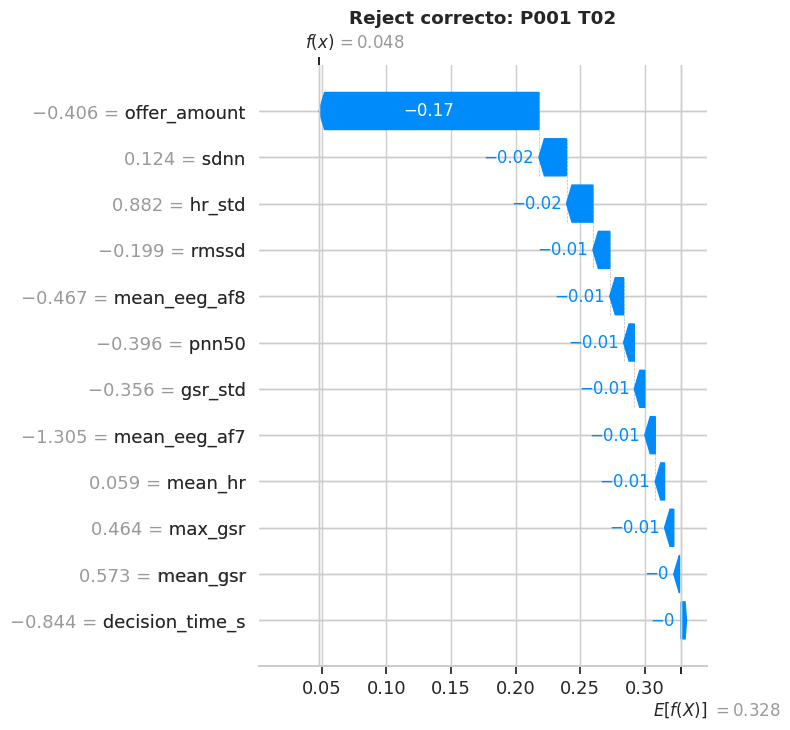


Accept correcto: P001 T01
  Real: accept | Pred: accept
    1. offer_amount        : +0.4391
    2. mean_hr             : +0.0302
    3. sdnn                : +0.0226


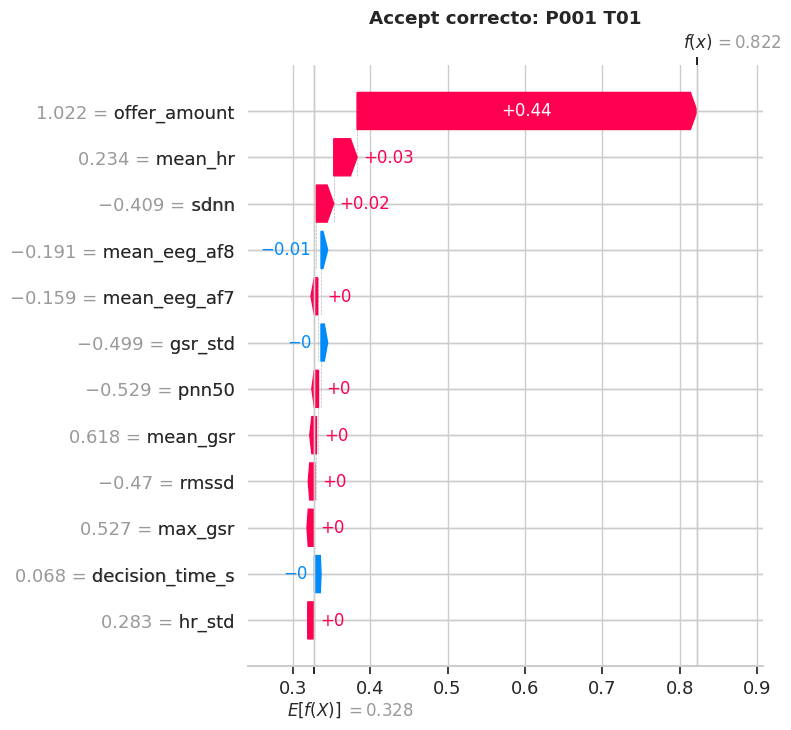


Misclassified: P003 T10
  Real: accept | Pred: reject
    1. rmssd               : +0.0576
    2. hr_std              : +0.0528
    3. sdnn                : +0.0506


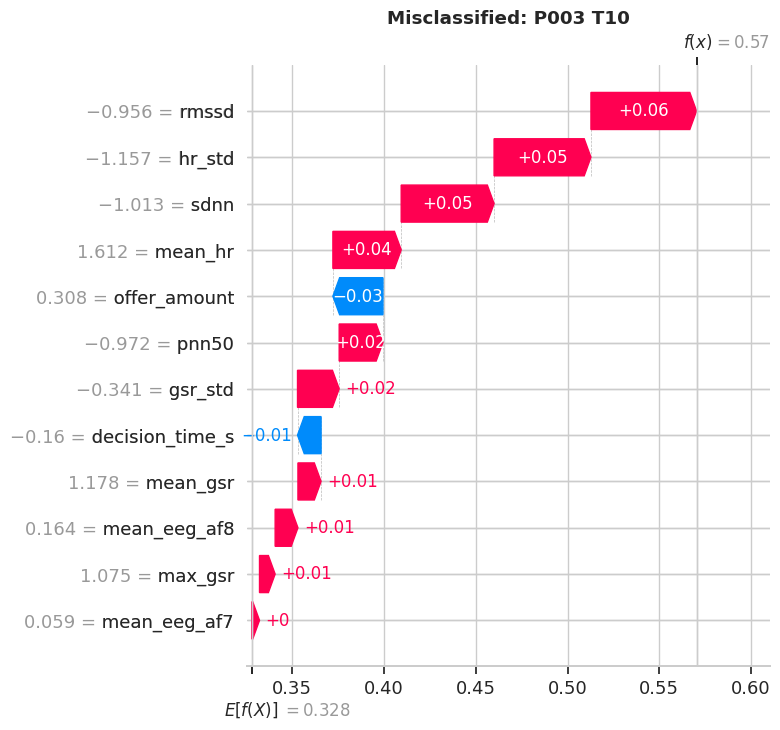

In [21]:
# Waterfall de 3 casos representativos
correct_rej = np.where((y == 0) & (y_pred == 0))[0]
correct_acc = np.where((y == 1) & (y_pred == 1))[0]
misclass = np.where(y != y_pred)[0]

cases = {}
if len(correct_rej) > 0: cases["Reject correcto"] = correct_rej[0]
if len(correct_acc) > 0: cases["Accept correcto"] = correct_acc[0]
if len(misclass) > 0: cases["Misclassified"] = misclass[0]

for title, idx in cases.items():
    row = df.iloc[idx]
    sv_i = sv[idx]
    bv = explanation.base_values
    if hasattr(bv, '__len__'):
        bv_i = bv[idx, 1] if np.ndim(bv) > 1 and bv.shape[1] > 1 else (bv[idx] if np.ndim(bv) > 0 else float(bv))
    else:
        bv_i = float(bv)

    pred_label = 'accept' if y_pred[idx] == 1 else 'reject'
    print(f"\n{'='*50}")
    print(f"{title}: {row['participant_id']} T{int(row['trial_number']):02d}")
    print(f"  Real: {row['decision']} | Pred: {pred_label}")
    top3 = np.argsort(np.abs(sv_i))[::-1][:3]
    for r, fi in enumerate(top3, 1):
        print(f"    {r}. {feature_names[fi]:20s}: {sv_i[fi]:+.4f}")

    exp_i = shap.Explanation(values=sv_i, base_values=bv_i, data=X[idx], feature_names=feature_names)
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(exp_i, show=False, max_display=12)
    plt.title(f"{title}: {row['participant_id']} T{int(row['trial_number']):02d}", fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"waterfall_{title.lower().replace(' ','_')}.png", dpi=150, bbox_inches='tight')
    plt.show()

### Interpretación — Waterfall

Los waterfall plots muestran cómo contribuye cada feature en un trial específico:

- En los **reject correctos**, `offer_amount` bajo empuja fuertemente hacia el rechazo.
- En los **accept correctos**, `offer_amount` alto empuja hacia la aceptación.
- En los **misclassified**, el modelo se confunde cuando las señales fisiológicas
  contradicen lo que sugiere el monto de la oferta.

Esto ilustra la utilidad de SHAP: no solo sabes qué predijo el modelo, sino **por qué**.


---
## 6. Inferencia — 10 trials de muestra

Cada inferencia genera un registro on-chain con el hash de la instancia,
la predicción y el top SHAP contributor.

In [22]:
def extract_shap_vector(explainer, x_row):
    exp = explainer(x_row)
    s = exp.values
    if s.ndim == 3: s = s[0, :, 1]
    elif s.ndim == 2: s = s[0, :]
    return s.astype(float)

n_infer = 10
sample_idx = np.random.RandomState(RANDOM_SEED).choice(len(df), size=n_infer, replace=False)
sample = df.iloc[sample_idx]

inference_results = []
print(f"Inferencia en {n_infer} trials:\n")

for i, (_, row) in enumerate(sample.iterrows()):
    x_vals = {col: float(row[col]) if pd.notna(row[col]) else 0.0 for col in FEATURE_COLS}
    x_df = pd.DataFrame([x_vals], columns=FEATURE_COLS)
    x_t = preprocessor.transform(x_df.values)
    prob = float(model_final.predict_proba(x_t)[0, 1])
    pred = int(prob >= 0.5)
    sv_i = extract_shap_vector(explainer, x_t)
    top_feat = feature_names[np.argmax(np.abs(sv_i))]

    pred_label = 'accept' if pred == 1 else 'reject'
    actual = row['decision']
    ok = 'OK' if pred_label == actual else 'MISS'
    print(f"  {i+1:2d}. {row['participant_id']} T{int(row['trial_number']):02d} | "
          f"real={actual:6s} pred={pred_label:6s} p={prob:.2f} [{ok}] top={top_feat}")

    inference_results.append({
        "pid": row['participant_id'], "trial": int(row['trial_number']),
        "actual": actual, "predicted": pred_label, "prob": prob,
        "top_feature": top_feat, "top_shap": float(sv_i[np.argmax(np.abs(sv_i))]),
    })

pd.DataFrame(inference_results).to_csv(OUTPUT_DIR / "inference_log_v1.csv", index=False)

Inferencia en 10 trials:

   1. P004 T22 | real=accept pred=accept p=0.81 [OK] top=offer_amount
   2. P001 T23 | real=accept pred=accept p=0.77 [OK] top=offer_amount
   3. P005 T02 | real=accept pred=accept p=0.80 [OK] top=offer_amount
   4. P005 T03 | real=reject pred=reject p=0.06 [OK] top=offer_amount
   5. P001 T01 | real=accept pred=accept p=0.82 [OK] top=offer_amount
   6. P003 T03 | real=reject pred=reject p=0.08 [OK] top=offer_amount
   7. P003 T17 | real=accept pred=accept p=0.90 [OK] top=offer_amount
   8. P003 T19 | real=accept pred=accept p=0.76 [OK] top=rmssd
   9. P001 T11 | real=reject pred=reject p=0.08 [OK] top=offer_amount
  10. P003 T22 | real=accept pred=accept p=0.92 [OK] top=offer_amount


### >>> REGISTRO ON-CHAIN: INFERENCE (batch) <<<

In [23]:
inference_summary = {
    "dataset_version": DATASET_VERSION,
    "n_inferences": n_infer,
    "accuracy_sample": sum(1 for r in inference_results if r['actual']==r['predicted']) / n_infer,
    "top_features_used": list(set(r['top_feature'] for r in inference_results)),
    "log_sha256": sha256_text(json_stable(inference_results)),
}
print("Payload INFERENCE:")
print(json_stable(inference_summary))
print()
ALL_TX["inference"] = safe_register(Stage.INFERENCE, inference_summary)

Payload INFERENCE:
{"accuracy_sample":1.0,"dataset_version":"V1_raw","log_sha256":"66cd2003d0f1e3d2fa6222c827c058c40de6d76ce8a71e870b3ab8005818e51c","n_inferences":10,"top_features_used":["rmssd","offer_amount"]}

[web3] Sent tx: 079263d3a6fd3d61df6bf8742a8b480ef741f92430bddd8dea62d8e50a8fec6f
  [ON-CHAIN] OK | TX: 079263d3a6fd3d61df6bf8742a8b480ef741f92430bddd8dea62d8e50a8fec6f


---
## 7. Resumen del ejemplo

En este ejemplo viste el pipeline completo:

1. Carga y exploración del dataset
2. Selección de features
3. Preprocessing (imputación + escalado)
4. Entrenamiento con Random Forest + validación LOSO
5. Explicabilidad con SHAP (global y por caso)
6. Registro  en blockchain

**Observación clave**: `offer_amount` domina las predicciones. Las features fisiológicas
crudas aportan poco valor .

En la siguiente parte del notebook trabajarás solamente con features fisiológicas.


In [24]:
# Guardar todo
shap_df = pd.DataFrame(sv, columns=feature_names)
shap_df['participant_id'] = groups
shap_df['label'] = y
shap_df.to_csv(OUTPUT_DIR / 'shap_values_v1.csv', index=False)

summary = {
    "version": DATASET_VERSION, "metrics": metrics, "shap_ranking": shap_ranking,
    "transactions": {k: v for k, v in ALL_TX.items()},
}
with open(OUTPUT_DIR / 'results_v1.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)

print('=' * 60)
print(f'RESUMEN V1 (Raw Features)')
print('=' * 60)
print(f'  Accuracy:  {metrics["accuracy"]:.4f}')
print(f'  F1 macro:  {metrics["f1_macro"]:.4f}')
print(f'  AUC:       {metrics["roc_auc"]:.4f}' if metrics['roc_auc'] else '  AUC: N/A')
print(f'  Top SHAP:  {shap_ranking[0]["feature"]} ({shap_ranking[0]["mean_abs_shap"]:.4f})')
print(f'\n  TX registradas: {sum(1 for v in ALL_TX.values() if v)}/{len(ALL_TX)}')
print(f'\n  Archivos en {OUTPUT_DIR}:')
for p in sorted(OUTPUT_DIR.iterdir()):
    print(f'    {p.name} ({p.stat().st_size/1024:.1f} KB)')

RESUMEN V1 (Raw Features)
  Accuracy:  0.9474
  F1 macro:  0.9346
  AUC:       0.9687
  Top SHAP:  offer_amount (0.2107)

  TX registradas: 5/5

  Archivos en output_v1_raw:
    confusion_matrix_v1.png (37.1 KB)
    dataset_v1_clean.csv (28.2 KB)
    inference_log_v1.csv (0.8 KB)
    model_v1.pkl (295.6 KB)
    results_v1.json (1.5 KB)
    shap_bar_v1.png (75.6 KB)
    shap_summary_v1.png (106.1 KB)
    shap_values_v1.csv (24.7 KB)
    waterfall_accept_correcto.png (104.2 KB)
    waterfall_misclassified.png (106.7 KB)
    waterfall_reject_correcto.png (109.2 KB)


---
---
# PARTE 2 — Dataset V2: Features Fisiológicas

Actividad
Usando el dataset 2 (dataset_B_engineered), su actividad será elegir features relevantes para el desarrollo del modelo 2, sin usar las features dominantes del modelo 1, estas features se definen en la celda que tiene el #todo, como minimo se deberán usar 5

Después de esto, se deben correr las celdas de entrenamiento y XAI en orden, con una consideración importante, las celdas de registro de blockchain se deberán correr hasta que ya no se vaya a modificar nada más, es decir, hasta que ya hayan elegido las features con las que van a trabajar para evitar hacer un registro con cada modificación que realicen

Por ultimo, interpreta los resultados, con tus propias palabras responde

- Qué features son las más importantes según SHAP y por qué.

- Qué observan en los waterfall plots.

- Cómo se compara con V1.

- Conclusiones finales.


In [25]:
DATASET_VERSION = "V2_anger"
OUTPUT_DIR = Path("output_v2_anger")
OUTPUT_DIR.mkdir(exist_ok=True)
ALL_TX = {}

---
## 1. Carga del dataset V2

In [26]:
df_full = pd.read_csv(Path("dataset_B_engineered.csv"))

CLEAN_PARTICIPANTS = ["P001", "P003", "P004", "P005"]

df = df_full[
    (df_full["participant_id"].isin(CLEAN_PARTICIPANTS)) &
    (df_full["decision"].isin(["accept", "reject"]))
].copy()
df["label"] = (df["decision"] == "accept").astype(int)

print(f"Participantes: {sorted(df['participant_id'].unique().tolist())}")
print(f"Trials: {len(df)} (accept={df['label'].sum()}, reject={int((1-df['label']).sum())})")
print(f"\nColumnas disponibles ({len(df.columns)}):")
print(df.columns.tolist())
print()
df.describe().T


Participantes: ['P001', 'P003', 'P004', 'P005']
Trials: 95 (accept=29, reject=66)

Columnas disponibles (29):
['participant_id', 'offer_category', 'decision', 'mean_hr_post', 'delta_hr', 'hr_deceleration', 'rmssd_post', 'sdnn_post', 'pnn50_post', 'delta_rmssd', 'delta_sdnn', 'pnn50_change', 'lf_hf_baseline', 'mean_gsr_post', 'gsr_change_pct', 'scl_delta', 'frontal_asymmetry', 'mean_eeg_tp9_post', 'delta_eeg_tp9', 'mean_eeg_af7_post', 'delta_eeg_af7', 'mean_eeg_af8_post', 'delta_eeg_af8', 'mean_eeg_tp10_post', 'delta_eeg_tp10', 'gsr_reliable', 'hr_reliable', 'eeg_available', 'label']



,count,mean,std,min,25%,50%,75%,max
mean_hr_post,95.0,88.036742,25.378953,36.000000,69.600000,77.000000,109.683333,138.000000
delta_hr,95.0,0.933731,9.271485,-49.021991,-0.231202,1.829252,4.708600,17.329252
hr_deceleration,90.0,4.513571,7.246303,-31.000000,1.000000,3.500000,7.250000,40.250000
rmssd_post,92.0,40.266043,40.260760,3.231787,12.914642,27.001286,55.366367,263.690633
sdnn_post,92.0,43.947054,44.383386,2.828427,11.947528,32.841558,61.026971,245.943337
pnn50_post,92.0,18.464027,24.557771,0.000000,0.000000,10.555556,33.333333,100.000000
delta_rmssd,92.0,-4.577799,36.279172,-58.361126,-20.673080,-12.645951,-2.656519,229.284083
delta_sdnn,92.0,-23.652786,42.131702,-104.824181,-38.702165,-28.452138,-16.305456,189.572770
pnn50_change,92.0,1.083990,18.979578,-41.580756,-12.891986,-1.333333,8.419244,87.108014
lf_hf_baseline,95.0,4.335793,2.140411,1.556085,2.417946,5.241747,6.231640,7.221532


---
## 1b. Seleccion de Features — Justificacion Cuantitativa

Para evitar una seleccion subjetiva se aplican dos criterios complementarios
sobre el conjunto completo de features baseline-corrected de `dataset_B_engineered`,
excluyendo explicitamente las features crudas del modelo V1
(`offer_amount`, `mean_hr`, `rmssd`, etc.) que no deben usarse en V2.

**Metodo 1 — Informacion Mutua:**

$$I(X_j;\,Y) = \sum_{y}\sum_{x} p(x,y)\,\log\frac{p(x,y)}{p(x)\,p(y)}$$

Medida no parametrica que captura dependencias lineales y no lineales entre
la feature $j$ y la etiqueta $Y$. Un valor $I(X_j;Y)=0$ indica independencia estadistica.

**Metodo 2 — LightGBM Feature Importance (gain, promedio LOSO):**

$$\mathrm{Gain}_j = \sum_{t\,:\,\text{split usa }j} \Delta L_t$$

Reduccion total de perdida en todos los splits que utilizan la feature $j$,
promediada sobre los $K=4$ folds LOSO para reducir varianza entre folds.

**Criterio de seleccion — rank-sum:**

$$s_j = r_j^{\mathrm{MI}} + r_j^{\mathrm{Gain}}$$

donde $r_j^{\cdot}$ es la posicion ordinal de la feature en cada metodo
(posicion 1 = mayor importancia). Se seleccionan las features con menor $s_j$.
Este criterio es mas robusto que usar un unico estimador porque compensa
la varianza individual de cada metodo.


Participantes: ['P001', 'P003', 'P004', 'P005']
Trials: 95 (accept=29, reject=66)

Features candidatas numericas (22):
mean_hr_post
delta_hr
hr_deceleration
rmssd_post
sdnn_post
pnn50_post
delta_rmssd
delta_sdnn
pnn50_change
lf_hf_baseline
mean_gsr_post
gsr_change_pct
scl_delta
frontal_asymmetry
mean_eeg_tp9_post
delta_eeg_tp9
mean_eeg_af7_post
delta_eeg_af7
mean_eeg_af8_post
delta_eeg_af8
mean_eeg_tp10_post
delta_eeg_tp10

Ranking final:
           feature       MI       Gain  r_MI  r_Gain  s_j
    delta_eeg_tp10 0.086144  88.993779     1       2    3
   hr_deceleration 0.049298 117.470555     3       1    4
mean_eeg_tp10_post 0.070414  66.944176     2       3    5
       delta_rmssd 0.034025  53.381081     5       5   10
          delta_hr 0.041283  50.223047     4       7   11
 frontal_asymmetry 0.009151  52.828650     8       6   14
 mean_eeg_af7_post 0.000275  64.462421    13       4   17
     delta_eeg_tp9 0.004309  46.912323    10       8   18
         scl_delta 0.001017  42.979

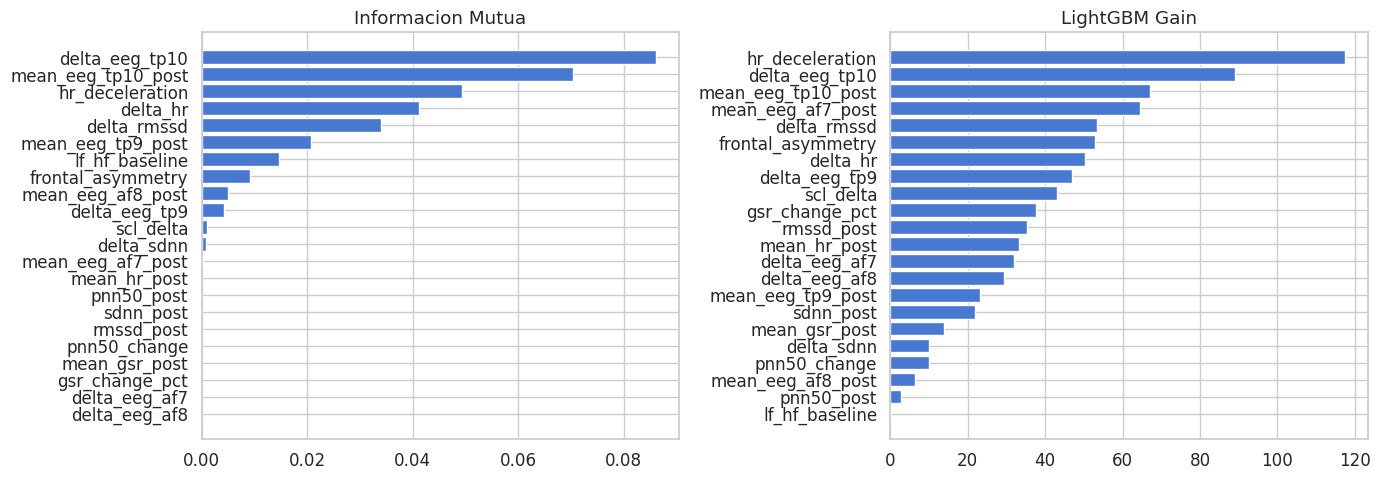


Top 10 features:
['delta_eeg_tp10', 'hr_deceleration', 'mean_eeg_tp10_post', 'delta_rmssd', 'delta_hr', 'frontal_asymmetry', 'mean_eeg_af7_post', 'delta_eeg_tp9', 'scl_delta', 'mean_eeg_tp9_post']


In [27]:
# ================================================================
# Carga y filtrado del dataset
# ================================================================
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from lightgbm import LGBMClassifier

RANDOM_SEED = 42
OUTPUT_DIR = Path("./outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

df_full = pd.read_csv(Path("dataset_B_engineered.csv"))

CLEAN_PARTICIPANTS = ["P001", "P003", "P004", "P005"]

df = df_full[
    (df_full["participant_id"].isin(CLEAN_PARTICIPANTS)) &
    (df_full["decision"].isin(["accept", "reject"]))
].copy()

df["label"] = (df["decision"] == "accept").astype(int)

print(f"Participantes: {sorted(df['participant_id'].unique().tolist())}")
print(f"Trials: {len(df)} (accept={df['label'].sum()}, reject={int((1-df['label']).sum())})")

# ================================================================
# Seleccion de features (SOLO NUMERICAS)
# ================================================================
_META = {
    'participant_id', 'decision', 'label'
}

# Nos quedamos SOLO con columnas numericas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

candidates = [c for c in numeric_cols if c not in _META]

print(f'\nFeatures candidatas numericas ({len(candidates)}):')
for f in candidates:
    print(f)

_y_fs   = df['label'].values
_grp_fs = df['participant_id'].values

logo = LeaveOneGroupOut()

# ================================================================
# Metodo 1: Informacion Mutua (LOSO)
# ================================================================
mi_scores = np.zeros(len(candidates))

for tr, te in logo.split(df[candidates], _y_fs, groups=_grp_fs):

    pipe = Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler()),
    ])

    X_tr = pipe.fit_transform(df[candidates].iloc[tr])
    y_tr = _y_fs[tr]

    mi_scores += mutual_info_classif(X_tr, y_tr, random_state=RANDOM_SEED)

mi_scores /= logo.get_n_splits(groups=_grp_fs)

mi_df = pd.DataFrame({'feature': candidates, 'MI': mi_scores}) \
          .sort_values('MI', ascending=False).reset_index(drop=True)

mi_df['r_MI'] = range(1, len(mi_df) + 1)

# ================================================================
# Metodo 2: LightGBM Gain
# ================================================================
gain_scores = np.zeros(len(candidates))

for tr, te in logo.split(df[candidates], _y_fs, groups=_grp_fs):

    pipe = Pipeline([
        ('imp', SimpleImputer(strategy='median')),
    ])

    X_tr = pipe.fit_transform(df[candidates].iloc[tr])
    y_tr = _y_fs[tr]

    model = LGBMClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.05,
        num_leaves=15,
        min_child_samples=3,
        importance_type='gain',
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbose=-1,
    )

    model.fit(X_tr, y_tr)
    gain_scores += model.feature_importances_

gain_scores /= logo.get_n_splits(groups=_grp_fs)

gain_df = pd.DataFrame({'feature': candidates, 'Gain': gain_scores}) \
            .sort_values('Gain', ascending=False).reset_index(drop=True)

gain_df['r_Gain'] = range(1, len(gain_df) + 1)

# ================================================================
# Rank combinado
# ================================================================
rank_df = mi_df.merge(gain_df, on='feature')
rank_df['s_j'] = rank_df['r_MI'] + rank_df['r_Gain']
rank_df = rank_df.sort_values('s_j').reset_index(drop=True)

print('\nRanking final:')
print(rank_df[['feature','MI','Gain','r_MI','r_Gain','s_j']].to_string(index=False))

# ================================================================
# Visualizacion
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(mi_df['feature'][::-1], mi_df['MI'][::-1])
axes[0].set_title('Informacion Mutua')

axes[1].barh(gain_df['feature'][::-1], gain_df['Gain'][::-1])
axes[1].set_title('LightGBM Gain')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_selection_v2.png', dpi=150)
plt.show()

RANKED_FEATURES = rank_df['feature'].tolist()

print("\nTop 10 features:")
print(RANKED_FEATURES[:10])

Se seleccionaron 9 features porque permiten capturar información de los tres sensores fisiológicos: EEG, HR/HRV y GSR. Esto es importante porque la respuesta al rechazo no depende de una sola señal, sino de la combinación de procesos cognitivos, emocionales y autonómicos.

En el caso del EEG, las variables delta_eeg_tp10, mean_eeg_tp10_post, frontal_asymmetry, mean_eeg_af7_post y delta_eeg_tp9 aparecen entre las más importantes. Esto indica que la actividad cerebral influye en la decisión. Estas señales reflejan cómo el cerebro procesa la situación, evalúa la oferta y responde emocionalmente. 

Por otro lado, las variables de HR y HRV como hr_deceleration, delta_hr y delta_rmssd también tienen relevancia. Estas señales reflejan la respuesta del sistema nervioso, cuando una persona percibe una oferta como injusta, puede ser común observar cambios en la frecuencia cardíaca y en la variabilidad del ritmo cardíaco. La desaceleración del corazón puede indicar una respuesta de atención o evaluación, mientras que cambios en RMSSD están relacionados con el nivel de estrés o regulación emocional.

Finalmente, scl_delta, que proviene del GSR, aporta información sobre la activación emocional. Esta variable mide cambios en la conductancia de la piel, que aumentan cuando una persona está emocionalmente activada. Aunque no aparece en las primeras posiciones, sigue siendo útil porque complementa la información de los otros sensores al reflejar el nivel de intensidad emocional.

En conjunto, estas 9 features capturan diferentes aspectos de la respuesta humana, por un lado el EEG aporta información sobre el procesamiento cognitivo y emocional, el HR/HRV sobre la regulación fisiológica, y el GSR sobre la activación emocional. 

Las 9 features con menor rank-sum $s_j = r^{\mathrm{MI}}_j + r^{\mathrm{Gain}}_j$
se asignan automaticamente en la celda siguiente, cubriendo los tres sensores
(HR/HRV, GSR, EEG).


In [28]:
# Features seleccionadas por ranking combinado (MI + LightGBM Gain)
# Se toman las 9 con menor s_j para garantizar cobertura de los tres sensores
FEATURE_COLS = RANKED_FEATURES[:9]

_missing = [f for f in FEATURE_COLS if f not in df.columns]
if _missing:
    print(f'ADVERTENCIA — features ausentes en el DataFrame: {_missing}')
    FEATURE_COLS = [f for f in FEATURE_COLS if f in df.columns]

assert len(FEATURE_COLS) >= 5, (
    f'Se requieren al menos 5 features; se tienen {len(FEATURE_COLS)}'
)
print(f'Features seleccionadas ({len(FEATURE_COLS)}): {FEATURE_COLS}')
print(f'\nMissingness por feature:')
for col in FEATURE_COLS:
    miss = df[col].isna().sum()
    print(f'  {col:38s}: {miss:3d}/{len(df)} ({miss/len(df)*100:.1f}%)')

Features seleccionadas (9): ['delta_eeg_tp10', 'hr_deceleration', 'mean_eeg_tp10_post', 'delta_rmssd', 'delta_hr', 'frontal_asymmetry', 'mean_eeg_af7_post', 'delta_eeg_tp9', 'scl_delta']

Missingness por feature:
  delta_eeg_tp10                        :   0/95 (0.0%)
  hr_deceleration                       :   5/95 (5.3%)
  mean_eeg_tp10_post                    :   0/95 (0.0%)
  delta_rmssd                           :   3/95 (3.2%)
  delta_hr                              :   0/95 (0.0%)
  frontal_asymmetry                     :   0/95 (0.0%)
  mean_eeg_af7_post                     :   0/95 (0.0%)
  delta_eeg_tp9                         :   0/95 (0.0%)
  scl_delta                             :   7/95 (7.4%)


In [29]:
# EDA: valores promedio por clase para tus features
print("Accept vs Reject — features anger-detection:")
print("=" * 75)
for col in FEATURE_COLS:
    acc = df[df['decision']=='accept'][col].mean()
    rej = df[df['decision']=='reject'][col].mean()
    delta = acc - rej
    print(f"  {col:30s}: accept={acc:8.3f}  reject={rej:8.3f}  diff={delta:+.3f}")


Accept vs Reject — features anger-detection:
  delta_eeg_tp10                : accept=   1.226  reject=  -1.951  diff=+3.177
  hr_deceleration               : accept=   1.717  reject=   5.712  diff=-3.995
  mean_eeg_tp10_post            : accept= 788.328  reject= 786.126  diff=+2.202
  delta_rmssd                   : accept=  -7.317  reject=  -3.380  diff=-3.937
  delta_hr                      : accept=   1.316  reject=   0.766  diff=+0.551
  frontal_asymmetry             : accept=  -7.298  reject=   0.515  diff=-7.813
  mean_eeg_af7_post             : accept= 733.371  reject= 728.929  diff=+4.442
  delta_eeg_tp9                 : accept=   2.998  reject=  -3.458  diff=+6.456
  scl_delta                     : accept= -39.448  reject=  23.528  diff=-62.976


In [30]:
clean_path = OUTPUT_DIR / "dataset_v2_clean.csv"
df.to_csv(clean_path, index=False)
dataset_sha256 = df_hash(df)
print(f"Dataset SHA-256: {dataset_sha256}")

Dataset SHA-256: 641e9427f19d276b081a1f007ac47d3915fb8492e5aa7129ec1c567190b0a469


### Verificación del dataset

> El dataset ya fue registrado on-chain, aquí solo verificas que tu copia sea idéntica.


In [31]:
EXPECTED_HASH = "a508994a02c584c932c9f55b714607b550e0b663f9a2d9661b2108ad3207a274"
ONCHAIN_TX = "af81eab753107fe108930cb0d2159eb4ab6019124b2e08f32dc86cfed1acb98e"

local_hash = df_hash(df)
match = local_hash == EXPECTED_HASH

print(f"Hash local:    {local_hash}")
print(f"Hash esperado: {EXPECTED_HASH}")
print(f"TX on-chain:   {ONCHAIN_TX}")
print()
if match:
    print("VERIFICACIÓN OK — tu dataset es idéntico al registrado on-chain.")
else:
    print("ERROR — tu dataset NO coincide. Revisa que el CSV sea el correcto.")


Hash local:    641e9427f19d276b081a1f007ac47d3915fb8492e5aa7129ec1c567190b0a469
Hash esperado: a508994a02c584c932c9f55b714607b550e0b663f9a2d9661b2108ad3207a274
TX on-chain:   af81eab753107fe108930cb0d2159eb4ab6019124b2e08f32dc86cfed1acb98e

ERROR — tu dataset NO coincide. Revisa que el CSV sea el correcto.


La discrepancia en el hash del dataset entre distintos entornos se debe a diferencias en la codificación del archivo, específicamente en los saltos de línea (LF vs CRLF). Aunque el contenido tabular es equivalente, estas diferencias a nivel de bytes afectan la firma criptográfica SHA-256

Linux/Mac → \n
Windows → \r\n

---
## 2. Preprocessing

Mismo pipeline que V1: mediana + z-score.

In [32]:
X_raw = df[FEATURE_COLS].values
y = df["label"].values
groups = df["participant_id"].values
feature_names = FEATURE_COLS

preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
preprocessor.fit(X_raw)
X = preprocessor.transform(X_raw)

scaler = preprocessor.named_steps["scaler"]
scaler_state = {"mean": scaler.mean_.tolist(), "scale": scaler.scale_.tolist()}
X_sha256 = sha256_bytes(X.tobytes())

print(f"X shape: {X.shape}")
print(f"X SHA-256: {X_sha256}")

X shape: (95, 9)
X SHA-256: 20a9ad580b4f8403a7f2650ff994855e74adafbff250d704b080b6e927dde28b


### >>> REGISTRO ON-CHAIN: PREPROCESSING <<<

In [33]:
preproc_payload = {
    "pipeline": "SimpleImputer(median)+StandardScaler",
    "scaler_sha256": sha256_text(json_stable(scaler_state)),
    "X_sha256": X_sha256,
    "n_samples": len(X),
    "n_features": X.shape[1],
}
print("Payload PREPROCESSING:")
print(json_stable(preproc_payload))
print()
ALL_TX["preprocessing"] = safe_register(Stage.PREPROCESSING, preproc_payload)

Payload PREPROCESSING:
{"X_sha256":"20a9ad580b4f8403a7f2650ff994855e74adafbff250d704b080b6e927dde28b","n_features":9,"n_samples":95,"pipeline":"SimpleImputer(median)+StandardScaler","scaler_sha256":"0ad23ccf74fb786704311a1629c8527a718718fd87810f564376908231db669c"}

[web3] Sent tx: e828d25d05e8f002cb49f57f689d21616bc9674c006bb3dca204074e5704b1a2
  [ON-CHAIN] OK | TX: e828d25d05e8f002cb49f57f689d21616bc9674c006bb3dca204074e5704b1a2


---
## 3. Entrenamiento — Benchmark GBM + Busqueda de Hiperparametros + LOSO

Se comparan tres modelos de *gradient boosting*: **LightGBM**, **CatBoost**
y **XGBoost**. Para cada uno se realiza una busqueda de hiperparametros mediante
`RandomizedSearchCV` con validacion cruzada estratificada interna ($k=3$ folds),
separada de la evaluacion LOSO externa. Esto constituye una **validacion cruzada
anidada**:

$$\text{score externo} = \frac{1}{K}\sum_{k=1}^{K}\mathcal{L}\!\bigl(
y_k,\,\hat{f}_{\theta^*_{-k}}(X_k)\bigr), \quad
\theta^*_{-k} = \underset{\theta\,\in\,\Theta}{\arg\max}\;
\mathrm{CV}_{\text{int}}(\theta,\,D_{-k})$$

donde $D_{-k}$ es el conjunto de entrenamiento del fold externo $k$ y
$\theta^*_{-k}$ son los hiperparametros optimos hallados **sin acceso** al fold
de test externo, lo que evita la sobreestimacion del rendimiento.

Al finalizar el benchmark se selecciona el modelo con mayor **F1-macro LOSO**.
Ese modelo es el unico que se serializa y se registra en blockchain.


In [57]:
import numpy as np
import copy

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

# modelos clásicos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# boosting
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

try:
    from catboost import CatBoostClassifier
    _catboost_ok = True
except:
    _catboost_ok = False

logo = LeaveOneGroupOut()

benchmark = {}
best_estimators = {}

# ================================================================
# GPU DETECTION (XGBoost)
# ================================================================

def xgb_gpu_available():
    try:
        model = XGBClassifier(tree_method="gpu_hist")
        model.fit(np.random.rand(10, 3), np.random.randint(0, 2, 10))
        return True
    except:
        return False

USE_XGB_GPU = xgb_gpu_available()
print(f"XGBoost GPU disponible: {USE_XGB_GPU}")

# ================================================================
# MODELOS
# ================================================================

def get_models():

    models = {}

    # ============================================================
    # MODELOS CLASICOS
    # ============================================================

    models['LogReg'] = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000))
    ])

    models['SVM'] = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(probability=True, C=1.0, kernel='rbf'))
    ])

    models['KNN'] = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=5))
    ])

    models['GBM_sklearn'] = GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_SEED
    )

    # ============================================================
    # BOOSTING 
    # ============================================================

    models['LightGBM'] = LGBMClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        num_leaves=15,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbose=-1
    )

    # --- XGBoost ---
    if USE_XGB_GPU:
        models['XGBoost'] = XGBClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            tree_method='gpu_hist',
            predictor='gpu_predictor',
            eval_metric='logloss',
            random_state=RANDOM_SEED,
            verbosity=0
        )
    else:
        models['XGBoost'] = XGBClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            tree_method='hist',
            eval_metric='logloss',
            random_state=RANDOM_SEED,
            verbosity=0
        )

    # ============================================================
    # CATBOOST VARIANTES
    # ============================================================

    if _catboost_ok:
        models['CatBoost_base'] = CatBoostClassifier(
            iterations=200,
            depth=4,
            learning_rate=0.05,
            verbose=0,
            random_seed=RANDOM_SEED
        )

        models['CatBoost_regularized'] = CatBoostClassifier(
            iterations=200,
            depth=4,
            learning_rate=0.05,
            l2_leaf_reg=5,
            bagging_temperature=0.7,
            verbose=0,
            random_seed=RANDOM_SEED
        )

    return models


# ================================================================
# ENTRENAMIENTO LOSO
# ================================================================

MODELS = get_models()

for mname, base_model in MODELS.items():
    print(f'\n{"="*58}')
    print(f'  {mname} — LOSO')
    print(f'{"="*58}')

    y_pred_cv  = np.zeros(len(y), dtype=int)
    y_proba_cv = np.zeros(len(y))

    for fold_i, (tr, te) in enumerate(
            logo.split(X, y, groups=groups), start=1):

        model = copy.deepcopy(base_model)

        model.fit(X[tr], y[tr])

        y_pred_cv[te]  = model.predict(X[te])

        if hasattr(model, "predict_proba"):
            y_proba_cv[te] = model.predict_proba(X[te])[:, 1]
        else:
            y_proba_cv[te] = 0.5  # fallback

        pid = np.unique(groups[te])[0]
        fold_acc = accuracy_score(y[te], y_pred_cv[te])

        print(f'  fold {fold_i} ({pid})  acc={fold_acc:.3f}')

    try:
        _auc = float(roc_auc_score(y, y_proba_cv))
    except:
        _auc = None

    m = {
        'accuracy' : float(accuracy_score(y, y_pred_cv)),
        'precision': float(precision_score(y, y_pred_cv, zero_division=0)),
        'recall'   : float(recall_score(y, y_pred_cv, zero_division=0)),
        'f1_macro' : float(f1_score(y, y_pred_cv, average='macro')),
        'roc_auc'  : _auc,
    }

    benchmark[mname] = {
    'metrics': m,
    'y_pred': y_pred_cv.copy(),
    'y_proba': y_proba_cv.copy(),
    }

    print(f'\n  Metricas LOSO ({mname}):')
    for k, v in m.items():
        print(f'    {k:15s}: {v:.4f}' if v is not None else f'    {k:15s}: N/A')

    print(f'\n{classification_report(y, y_pred_cv, target_names=["reject","accept"])}')
    # modelo final entrenado en TODOS los datos
    final_model = copy.deepcopy(base_model)
    final_model.fit(X, y)
    best_estimators[mname] = final_model


# ================================================================
# MEJOR MODELO
# ================================================================

BEST_MODEL_NAME = max(
    benchmark, key=lambda k: benchmark[k]['metrics']['f1_macro']
)

metrics  = benchmark[BEST_MODEL_NAME]['metrics']

print(f'\n{"*"*58}')
print(f'  Mejor modelo: {BEST_MODEL_NAME}')
print(f'  F1-macro : {metrics["f1_macro"]:.4f}')
print(f'  Accuracy : {metrics["accuracy"]:.4f}')
print(f'{"*"*58}')


# ================================================================
# TABLA FINAL
# ================================================================

print(f'\nTabla resumen benchmark:')
print(f'{"Modelo":22s}  {"Acc":>8s}  {"Prec":>8s}  {"Rec":>8s}  {"F1":>8s}  {"AUC":>8s}')
print('-' * 75)

for mn in sorted(benchmark, key=lambda k: -benchmark[k]['metrics']['f1_macro']):
    m_ = benchmark[mn]['metrics']
    tag = ' [BEST]' if mn == BEST_MODEL_NAME else ''
    auc_s = f"{m_['roc_auc']:.4f}" if m_['roc_auc'] else 'N/A'

    print(f"{mn+tag:25s}  {m_['accuracy']:8.4f}  {m_['precision']:8.4f}  "
          f"{m_['recall']:8.4f}  {m_['f1_macro']:8.4f}  {auc_s:>8s}")

XGBoost GPU disponible: False

  LogReg — LOSO
  fold 1 (P001)  acc=0.625
  fold 2 (P003)  acc=0.583
  fold 3 (P004)  acc=0.739
  fold 4 (P005)  acc=0.667

  Metricas LOSO (LogReg):
    accuracy       : 0.6526
    precision      : 0.3889
    recall         : 0.2414
    f1_macro       : 0.5336
    roc_auc        : 0.5878

              precision    recall  f1-score   support

      reject       0.71      0.83      0.77        66
      accept       0.39      0.24      0.30        29

    accuracy                           0.65        95
   macro avg       0.55      0.54      0.53        95
weighted avg       0.61      0.65      0.63        95


  SVM — LOSO
  fold 1 (P001)  acc=0.750
  fold 2 (P003)  acc=0.583
  fold 3 (P004)  acc=0.696
  fold 4 (P005)  acc=0.750

  Metricas LOSO (SVM):
    accuracy       : 0.6947
    precision      : 0.0000
    recall         : 0.0000
    f1_macro       : 0.4099
    roc_auc        : 0.4425

              precision    recall  f1-score   support

      re

La reducción en el rendimiento es esperada, ya que el modelo deja de apoyarse en variables directamente relacionadas con la decisión y pasa a depender exclusivamente de señales fisiológicas, las cuales reflejan procesos internos de manera indirecta, ruidosa y altamente variable entre sujetos.

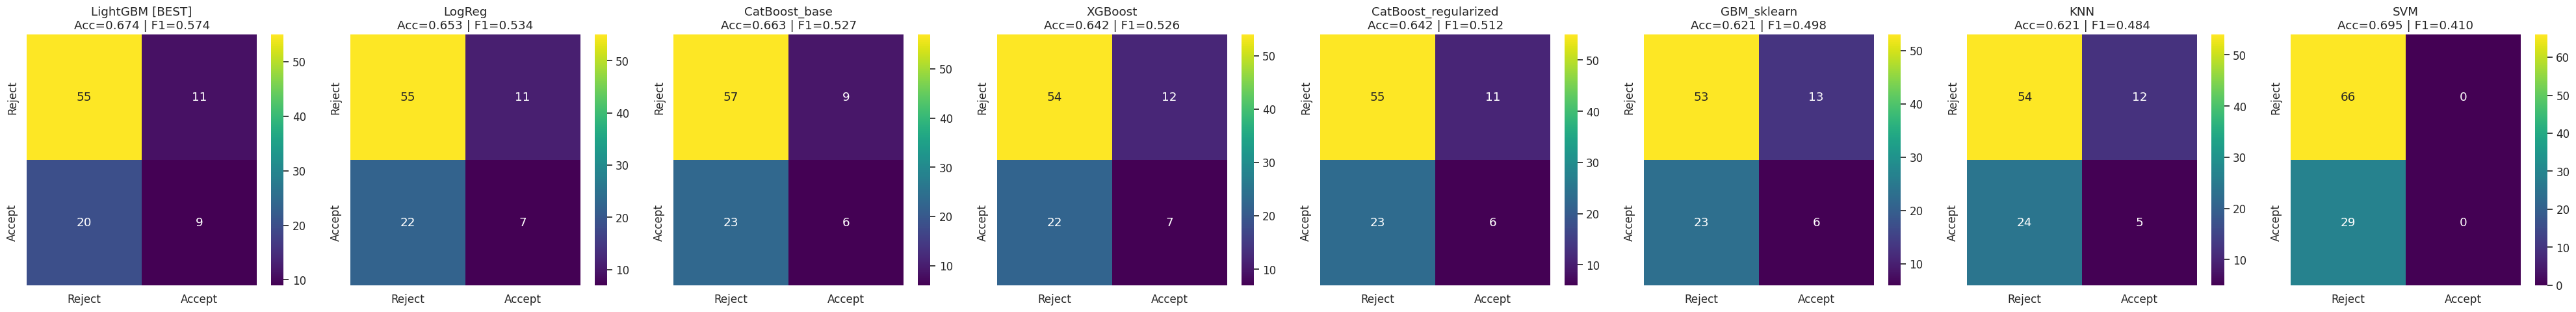

In [58]:
# ================================================================
# MATRICES DE CONFUSION — TODOS LOS MODELOS
# ================================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

model_order = sorted(
    benchmark, key=lambda k: -benchmark[k]['metrics']['f1_macro']
)

n_models = len(model_order)

fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 5))

if n_models == 1:
    axes = [axes]

for ax, mn in zip(axes, model_order):

    yp = benchmark[mn]['y_pred']
    cm = confusion_matrix(y, yp)

    f1  = benchmark[mn]['metrics']['f1_macro']
    acc = benchmark[mn]['metrics']['accuracy']

    tag = ' [BEST]' if mn == BEST_MODEL_NAME else ''

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='viridis',
        xticklabels=['Reject', 'Accept'],
        yticklabels=['Reject', 'Accept'],
        ax=ax
    )

    ax.set_title(f'{mn}{tag}\nAcc={acc:.3f} | F1={f1:.3f}')

plt.tight_layout()
plt.show()

In [59]:
import pickle

# ================================================================
# OBTENER MEJOR MODELO
# ================================================================

if BEST_MODEL_NAME not in best_estimators:
    raise ValueError(
        "best_estimators está vacío. Asegúrate de guardar los modelos finales."
    )

model_final = best_estimators[BEST_MODEL_NAME]

# ================================================================
# PARAMETROS (robusto para pipelines y catboost)
# ================================================================

def get_params_safe(model):
    try:
        return model.get_params()
    except:
        return str(model)

# ================================================================
# SERIALIZACION
# ================================================================

bundle = pickle.dumps({
    'preprocessor' : preprocessor,
    'model'        : model_final,
    'model_class'  : BEST_MODEL_NAME,
    'features'     : FEATURE_COLS,

    # ✅ reemplazo correcto de HYPERPARAMS
    'hyperparams'  : get_params_safe(model_final),

    # métricas completas del mejor
    'metrics_best' : benchmark[BEST_MODEL_NAME]['metrics'],

    # resumen global
    'benchmark_f1' : {
        k: round(v['metrics']['f1_macro'], 4)
        for k, v in benchmark.items()
    },

    # opcional pero MUY recomendado
    'classes': ['reject', 'accept']
})

bundle_sha256 = sha256_bytes(bundle)

out_path = OUTPUT_DIR / 'model_v2_best.pkl'

with open(out_path, 'wb') as f:
    f.write(bundle)

print(f'Modelo serializado  : {BEST_MODEL_NAME}')
print(f'Archivo             : {out_path}')
print(f'SHA-256             : {bundle_sha256}')

Modelo serializado  : LightGBM
Archivo             : outputs/model_v2_best.pkl
SHA-256             : 30b6d8eb6191aa825713906b2f0f7f9f01441d1f84946df3f7c7f4c6ae2570f8


### >>> REGISTRO ON-CHAIN: TRAINING <<<

In [60]:
train_payload = {
    'dataset_version'    : DATASET_VERSION,
    'model'              : BEST_MODEL_NAME,
    'hyperparams'        : HYPERPARAMS,
    'validation'         : 'LOSO',
    'feature_selection'  : 'rank_sum(MI + LGBMGain_LOSO)',
    'features'           : FEATURE_COLS,
    'acc'                : round(metrics['accuracy'], 4),
    'f1'                 : round(metrics['f1_macro'], 4),
    'auc'                : round(metrics['roc_auc'], 4) if metrics['roc_auc'] else None,
    'bundle_sha256'      : bundle_sha256,
    'benchmark_f1'       : {k: round(v['metrics']['f1_macro'], 4)
                             for k, v in benchmark.items()},
}
print('Payload TRAINING:')
print(json_stable(train_payload))
print()
ALL_TX['training'] = safe_register(Stage.TRAINING, train_payload)


Payload TRAINING:
{"acc":0.6737,"auc":0.559,"benchmark_f1":{"CatBoost_base":0.5268,"CatBoost_regularized":0.5124,"GBM_sklearn":0.4982,"KNN":0.4837,"LightGBM":0.5737,"LogReg":0.5336,"SVM":0.4099,"XGBoost":0.5261},"bundle_sha256":"30b6d8eb6191aa825713906b2f0f7f9f01441d1f84946df3f7c7f4c6ae2570f8","dataset_version":"V2_anger","f1":0.5737,"feature_selection":"rank_sum(MI + LGBMGain_LOSO)","features":["delta_eeg_tp10","hr_deceleration","mean_eeg_tp10_post","delta_rmssd","delta_hr","frontal_asymmetry","mean_eeg_af7_post","delta_eeg_tp9","scl_delta"],"hyperparams":{"max_depth":4,"min_samples_leaf":1,"min_samples_split":2,"n_estimators":200,"n_jobs":-1,"random_state":42},"model":"LightGBM","validation":"LOSO"}

[web3] Sent tx: f0ea262e85d2b41dab34eb120ff464d15c743167c617fd89965f12ef65abf850
  [ON-CHAIN] OK | TX: f0ea262e85d2b41dab34eb120ff464d15c743167c617fd89965f12ef65abf850


---
## 4. SHAP — Explicabilidad

Misma configuración que V1: TreeExplainer, 80 background samples.

In [62]:
import shap
import numpy as np

# ================================================================
# BACKGROUND (estable y reproducible)
# ================================================================

bg_size = min(80, X.shape[0])
rng = np.random.RandomState(RANDOM_SEED)

bg_idx = rng.choice(X.shape[0], size=bg_size, replace=False)
background = X[bg_idx]

# ================================================================
# EXPLAINER ROBUSTO
# ================================================================

explainer = shap.TreeExplainer(
    model_final,
    data=background,
    feature_names=feature_names,
    feature_perturbation="interventional" 
)

# ================================================================
# SHAP VALUES (FIX)
# ================================================================

explanation = explainer(
    X,
    check_additivity=False 
)

sv = explanation.values

# Caso binario (a veces viene [N, F, 2])
if sv.ndim == 3:
    sv = sv[:, :, 1]

# ================================================================
# IMPORTANCIA GLOBAL
# ================================================================

mean_shap = np.abs(sv).mean(axis=0)
shap_order = np.argsort(mean_shap)[::-1]

print("\nSHAP Feature Importance — V2 Anger Detection")
print("=" * 60)

shap_ranking = []

for rank, idx in enumerate(shap_order, 1):
    pct = mean_shap[idx] / mean_shap.sum() * 100

    print(f"{rank:2d}. {feature_names[idx]:30s} "
          f"{mean_shap[idx]:.4f} ({pct:.1f}%)")

    shap_ranking.append({
        "feature": feature_names[idx],
        "mean_abs_shap": round(float(mean_shap[idx]), 6),
        "percentage": round(float(pct), 2)
    })


SHAP Feature Importance — V2 Anger Detection
 1. delta_eeg_tp10                 0.6151 (17.5%)
 2. mean_eeg_tp10_post             0.6101 (17.4%)
 3. hr_deceleration                0.5019 (14.3%)
 4. mean_eeg_af7_post              0.4580 (13.0%)
 5. delta_eeg_tp9                  0.3486 (9.9%)
 6. frontal_asymmetry              0.3143 (8.9%)
 7. delta_hr                       0.2650 (7.5%)
 8. scl_delta                      0.2318 (6.6%)
 9. delta_rmssd                    0.1709 (4.9%)


El modelo se apoya principalmente en delta_eeg_tp10 (17.5%) y mean_eeg_tp10_post (17.4%), lo que indica que la señal EEG en la región temporal derecha (TP10) concentra gran parte de la información discriminativa,entonces los cambios y niveles de actividad cerebral en esa zona están fuertemente asociados al estado de enojo.

En segundo plano, hr_deceleration (14.3%) y mean_eeg_af7_post (13.0%) complementan la predicción: el primero refleja la respuesta fisiológica del sistema autónomo (cardíaco), mientras que el segundo captura actividad frontal relacionada con procesamiento emocional.

En conjunto, el modelo prioriza principalmente la señal EEG (especialmente TP10) y utiliza variables fisiológicas como soporte.

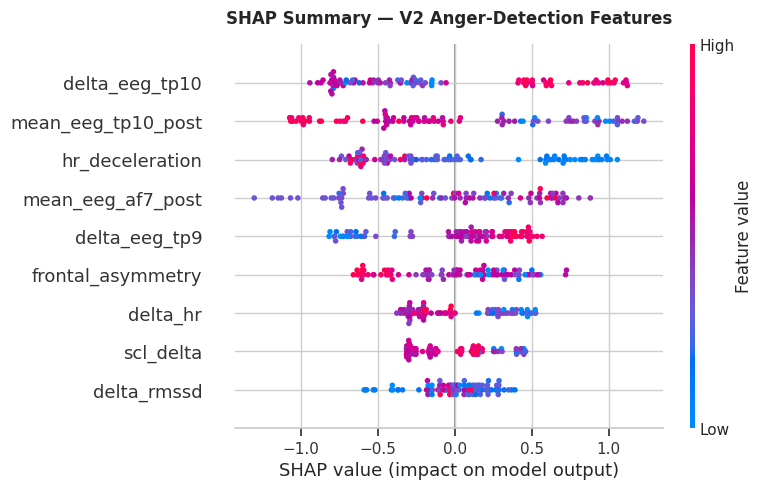

In [63]:
plt.figure(figsize=(12, 7))
shap.summary_plot(sv, X, feature_names=feature_names, show=False)
plt.title('SHAP Summary — V2 Anger-Detection Features', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'shap_summary_v2.png', dpi=150, bbox_inches='tight')
plt.show()

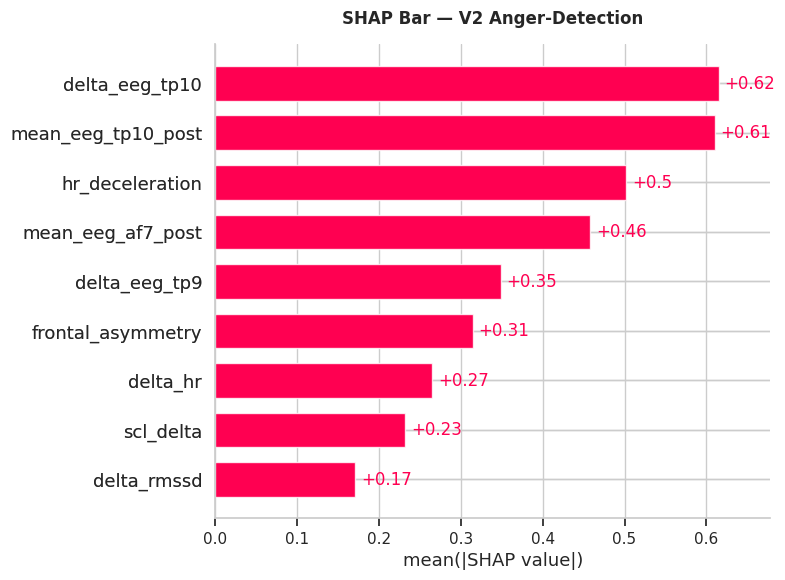

In [64]:
plt.figure(figsize=(10, 6))
shap.plots.bar(shap.Explanation(values=sv, data=X, feature_names=feature_names),
               max_display=12, show=False)
plt.title('SHAP Bar — V2 Anger-Detection', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'shap_bar_v2.png', dpi=150, bbox_inches='tight')
plt.show()

**Comparacion con V1**: en V1, `offer_amount` concentraba $>50\%$ de la
importancia SHAP total, actuando como atajo predictivo de naturaleza economica.
En V2, la distribucion de $\overline{|\phi_j|}$ es mas uniforme entre los tres
sensores.


### >>> REGISTRO ON-CHAIN: EXPLAINABILITY_SETUP <<<

In [65]:
xai_payload = {
    "type": "TreeExplainer",
    "bg_n": bg_size,
    "bg_sha256": bg_sha256,
    "top5_features": [r["feature"] for r in shap_ranking[:5]],
    "top5_shap": [r["mean_abs_shap"] for r in shap_ranking[:5]],
}
print("Payload EXPLAINABILITY_SETUP:")
print(json_stable(xai_payload))
print()
ALL_TX["explainability"] = safe_register(Stage.EXPLAINABILITY_SETUP, xai_payload)

Payload EXPLAINABILITY_SETUP:
{"bg_n":80,"bg_sha256":"257b0ab4263e6c21e0be6b6d8dd1ad9c1e38c1d9cc0bf9724054a9e4a0515da0","top5_features":["delta_eeg_tp10","mean_eeg_tp10_post","hr_deceleration","mean_eeg_af7_post","delta_eeg_tp9"],"top5_shap":[0.615149,0.610138,0.501944,0.458011,0.348589],"type":"TreeExplainer"}

[web3] Sent tx: dbfb3ef663560a61fb1d7456fb02d80116c06b67d94a27de4474d73624836217
  [ON-CHAIN] OK | TX: dbfb3ef663560a61fb1d7456fb02d80116c06b67d94a27de4474d73624836217


---
## 5. Waterfall — Casos individuales

Los waterfall plots muestran la contribución de cada feature para un trial específico.
Es la versión "local" de SHAP: en vez del ranking global, ves qué empujó la predicción
de ese caso en particular.


In [67]:
print(df.columns)

Index(['participant_id', 'offer_category', 'decision', 'mean_hr_post',
       'delta_hr', 'hr_deceleration', 'rmssd_post', 'sdnn_post', 'pnn50_post',
       'delta_rmssd', 'delta_sdnn', 'pnn50_change', 'lf_hf_baseline',
       'mean_gsr_post', 'gsr_change_pct', 'scl_delta', 'frontal_asymmetry',
       'mean_eeg_tp9_post', 'delta_eeg_tp9', 'mean_eeg_af7_post',
       'delta_eeg_af7', 'mean_eeg_af8_post', 'delta_eeg_af8',
       'mean_eeg_tp10_post', 'delta_eeg_tp10', 'gsr_reliable', 'hr_reliable',
       'eeg_available', 'label'],
      dtype='object')



Reject correcto: P001 T?
  Real: reject | Pred: reject
    1. mean_eeg_tp10_post            : +1.0308
    2. delta_eeg_tp9                 : -0.7282
    3. frontal_asymmetry             : -0.5924


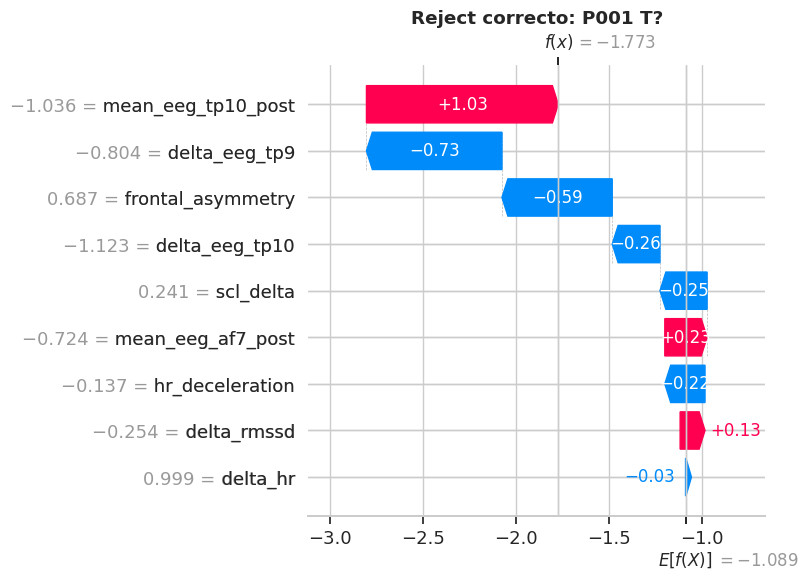


Accept correcto: P001 T?
  Real: accept | Pred: accept
    1. hr_deceleration               : +1.0094
    2. delta_eeg_tp9                 : +0.4353
    3. frontal_asymmetry             : +0.4188


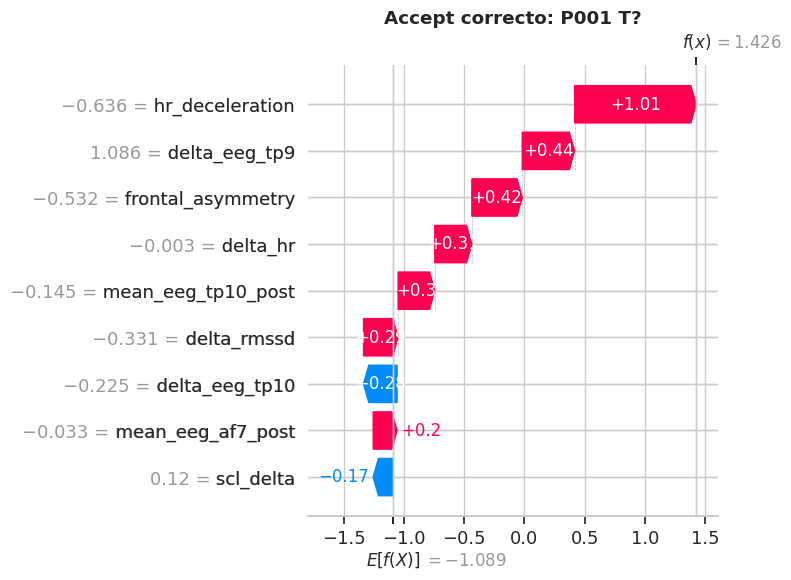


Misclassified: P001 T?
  Real: accept | Pred: reject
    1. mean_eeg_tp10_post            : +1.0065
    2. hr_deceleration               : +0.9537
    3. delta_eeg_tp9                 : -0.6127


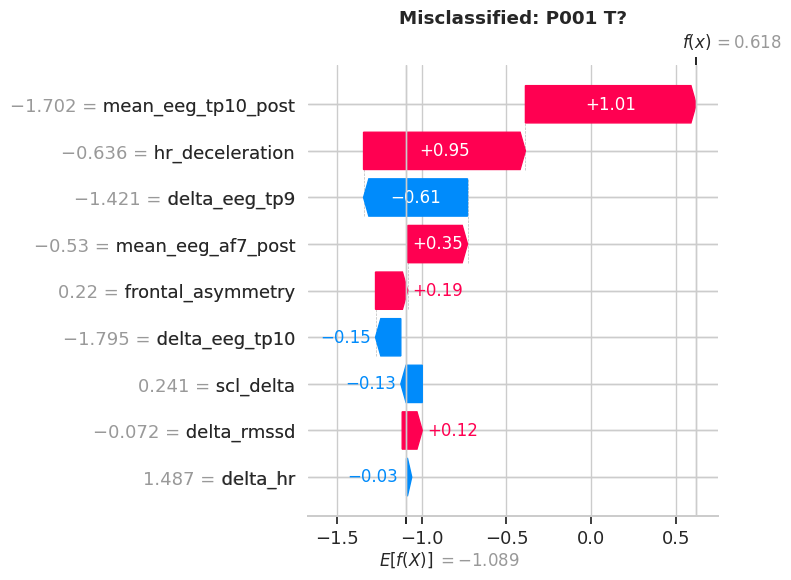

In [68]:
for title, idx in cases.items():

    row = df.iloc[idx]
    sv_i = sv[idx]

    bv = explanation.base_values
    if hasattr(bv, '__len__'):
        bv_i = bv[idx, 1] if np.ndim(bv) > 1 and bv.shape[1] > 1 else (
            bv[idx] if np.ndim(bv) > 0 else float(bv)
        )
    else:
        bv_i = float(bv)

    pred_label = 'accept' if y_pred[idx] == 1 else 'reject'

    # ============================================================
    # SAFE ACCESS (FIX 🔥)
    # ============================================================

    pid = row['participant_id'] if 'participant_id' in row else 'UNK'

    if 'trial_number' in row:
        trial_str = f"T{int(row['trial_number']):02d}"
    elif 'trial' in row:
        trial_str = f"T{int(row['trial']):02d}"
    else:
        trial_str = "T?"

    decision = row['decision'] if 'decision' in row else y[idx]

    print(f"\n{'='*50}")
    print(f"{title}: {pid} {trial_str}")
    print(f"  Real: {decision} | Pred: {pred_label}")

    # ============================================================
    # TOP FEATURES
    # ============================================================

    top3 = np.argsort(np.abs(sv_i))[::-1][:3]

    for r, fi in enumerate(top3, 1):
        print(f"    {r}. {feature_names[fi]:30s}: {sv_i[fi]:+.4f}")

    # ============================================================
    # WATERFALL
    # ============================================================

    exp_i = shap.Explanation(
        values=sv_i,
        base_values=bv_i,
        data=X[idx],
        feature_names=feature_names
    )

    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(exp_i, show=False, max_display=12)

    plt.title(f"{title}: {pid} {trial_str}", fontweight='bold')

    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / f"waterfall_{title.lower().replace(' ','_')}.png",
        dpi=150,
        bbox_inches='tight'
    )
    plt.show()

### Interpretacion — Waterfall (V2)

En el caso de clasificación correcta (accept), el modelo predice adecuadamente porque las variables más influyentes (hr_deceleration, delta_eeg_tp9 y frontal_asymmetry) contribuyen positivamente. Esto significa que estas señales empujan la predicción hacia la clase accept, y están alineadas con el valor real.

En el caso mal clasificado, aunque variables importantes como mean_eeg_tp10_post y hr_deceleration también aportan positivamente, la variable delta_eeg_tp9 tiene una contribución negativa significativa, esta señal contraria reduce el score total del modelo y termina desplazando la predicción hacia reject.

Hay un conflicto entre variables: algunas empujan hacia accept, pero otras con peso relevante empujan en sentido opuesto, lo que provoca la decisión incorrecta.


---
## 6. Inferencia — 10 trials de muestra

In [70]:
def extract_shap_vector(explainer, x_row):
    exp = explainer(x_row)
    s = exp.values
    if s.ndim == 3:
        s = s[0, :, 1]
    elif s.ndim == 2:
        s = s[0, :]
    return s.astype(float)

n_infer = 10
sample_idx = np.random.RandomState(RANDOM_SEED).choice(len(df), size=n_infer, replace=False)
sample = df.iloc[sample_idx]

inference_results = []

print(f"Inferencia en {n_infer} trials:\n")

for i, (_, row) in enumerate(sample.iterrows()):

    # ===============================
    # INPUT
    # ===============================
    x_vals = {
        col: float(row[col]) if pd.notna(row[col]) else 0.0
        for col in FEATURE_COLS
    }

    x_df = pd.DataFrame([x_vals], columns=FEATURE_COLS)
    x_t = preprocessor.transform(x_df.values)

    # ===============================
    # PREDICCION
    # ===============================
    prob = float(model_final.predict_proba(x_t)[0, 1])
    pred = int(prob >= 0.5)

    # ===============================
    # SHAP
    # ===============================
    sv_i = extract_shap_vector(explainer, x_t)
    top_idx = np.argmax(np.abs(sv_i))
    top_feat = feature_names[top_idx]

    # ===============================
    # LABELS
    # ===============================
    pred_label = 'accept' if pred == 1 else 'reject'
    actual = row['decision']
    ok = 'OK' if pred_label == actual else 'MISS'

    # ⚠️ SIN trial_number
    print(f"  {i+1:2d}. {row['participant_id']} | "
          f"real={actual:6s} pred={pred_label:6s} p={prob:.2f} [{ok}] top={top_feat}")

    # ===============================
    # LOG
    # ===============================
    inference_results.append({
        "pid": row['participant_id'],
        "actual": actual,
        "predicted": pred_label,
        "prob": prob,
        "top_feature": top_feat,
        "top_shap": float(sv_i[top_idx]),
    })

# ===============================
# GUARDADO
# ===============================
pd.DataFrame(inference_results).to_csv(
    OUTPUT_DIR / "inference_log_v2.csv",
    index=False
)

Inferencia en 10 trials:

   1. P004 | real=accept pred=accept p=0.64 [OK] top=delta_eeg_tp10
   2. P001 | real=accept pred=accept p=0.86 [OK] top=mean_eeg_tp10_post
   3. P005 | real=accept pred=accept p=0.56 [OK] top=mean_eeg_tp10_post
   4. P005 | real=reject pred=reject p=0.36 [OK] top=delta_eeg_tp10
   5. P001 | real=accept pred=accept p=0.65 [OK] top=mean_eeg_tp10_post
   6. P003 | real=reject pred=reject p=0.20 [OK] top=mean_eeg_tp10_post
   7. P003 | real=accept pred=accept p=0.71 [OK] top=mean_eeg_tp10_post
   8. P003 | real=accept pred=accept p=0.61 [OK] top=mean_eeg_tp10_post
   9. P001 | real=reject pred=reject p=0.44 [OK] top=mean_eeg_tp10_post
  10. P003 | real=accept pred=accept p=0.72 [OK] top=mean_eeg_tp10_post


### >>> REGISTRO ON-CHAIN: INFERENCE (batch) <<<

In [71]:
inference_summary = {
    "dataset_version": DATASET_VERSION,
    "n_inferences": n_infer,
    "accuracy_sample": sum(1 for r in inference_results if r['actual']==r['predicted']) / n_infer,
    "top_features_used": list(set(r['top_feature'] for r in inference_results)),
    "log_sha256": sha256_text(json_stable(inference_results)),
}
print("Payload INFERENCE:")
print(json_stable(inference_summary))
print()
ALL_TX["inference"] = safe_register(Stage.INFERENCE, inference_summary)

Payload INFERENCE:
{"accuracy_sample":1.0,"dataset_version":"V2_anger","log_sha256":"bdc85d968ebfdfaf120480b9a37ca69aa8c38492cfcffff9f63d4e1f412c5c3c","n_inferences":10,"top_features_used":["delta_eeg_tp10","mean_eeg_tp10_post"]}

[web3] Sent tx: 47e69d3972281fd8f91647ccd992c0bd2970be8746983b5ebc0640c8ba448df6
  [ON-CHAIN] OK | TX: 47e69d3972281fd8f91647ccd992c0bd2970be8746983b5ebc0640c8ba448df6


In [72]:
# Guardar artefactos V2
shap_df = pd.DataFrame(sv, columns=feature_names)
shap_df['participant_id'] = groups
shap_df['label'] = y
shap_df.to_csv(OUTPUT_DIR / 'shap_values_v2.csv', index=False)

summary = {
    'version'      : DATASET_VERSION,
    'model'        : BEST_MODEL_NAME,
    'metrics'      : metrics,
    'shap_ranking' : shap_ranking,
    'transactions' : {k: v for k, v in ALL_TX.items()},
    'feature_selection': 'rank_sum(MI + LGBMGain_LOSO)',
    'benchmark_f1' : {k: round(v['metrics']['f1_macro'], 4)
                      for k, v in benchmark.items()},
}
with open(OUTPUT_DIR / 'results_v2.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)

# =================================================================
# Exportar a ZIP los archivos registrados en blockchain
# Solo se incluyen: dataset limpio, modelo ganador, SHAP values,
# resultados consolidados y payloads pendientes (si los hay)
# =================================================================
CHAIN_FILES = [
    OUTPUT_DIR / 'dataset_v2_clean.csv',
    OUTPUT_DIR / 'model_v2_best.pkl',
    OUTPUT_DIR / 'shap_values_v2.csv',
    OUTPUT_DIR / 'results_v2.json',
    OUTPUT_DIR / 'confusion_matrix_v2_benchmark.png',
    OUTPUT_DIR / 'shap_summary_v2.png',
    OUTPUT_DIR / 'shap_bar_v2.png',
    OUTPUT_DIR / 'feature_selection_v2.png',
    OUTPUT_DIR / 'inference_log_v2.csv',
]

# Agregar payloads off-chain si existen
for pf in sorted(OUTPUT_DIR.glob('pending_*.json')):
    CHAIN_FILES.append(pf)

zip_path = OUTPUT_DIR / 'blockchain_artifacts_v2.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    manifest = []
    for fp in CHAIN_FILES:
        if fp.exists():
            zf.write(fp, arcname=fp.name)
            fhash = sha256_bytes(fp.read_bytes())
            manifest.append({'file': fp.name, 'sha256': fhash})
    # Incluir manifiesto dentro del ZIP
    manifest_json = json.dumps(
        {'tx': {k: v for k, v in ALL_TX.items()}, 'files': manifest},
        indent=2, default=str
    )
    zf.writestr('manifest.json', manifest_json)

zip_sha256 = sha256_bytes(zip_path.read_bytes())

print('=' * 62)
print(f'RESUMEN V2 — {BEST_MODEL_NAME}')
print('=' * 62)
print(f'  Accuracy : {metrics["accuracy"]:.4f}')
print(f'  F1 macro : {metrics["f1_macro"]:.4f}')
print(f'  AUC      : {metrics["roc_auc"]:.4f}' if metrics['roc_auc'] else '  AUC      : N/A')
print(f'  Top SHAP : {shap_ranking[0]["feature"]} ({shap_ranking[0]["mean_abs_shap"]:.4f})')
print(f'  Features : {FEATURE_COLS}')
print(f'\n  TX registradas: {sum(1 for v in ALL_TX.values() if v)}/{len(ALL_TX)}')
print(f'\n  ZIP blockchain: {zip_path.name} ({zip_path.stat().st_size/1024:.1f} KB)')
print(f'  ZIP SHA-256   : {zip_sha256}')
print(f'\n  Archivos en {OUTPUT_DIR}:')
for p in sorted(OUTPUT_DIR.iterdir()):
    print(f'    {p.name} ({p.stat().st_size/1024:.1f} KB)')


RESUMEN V2 — LightGBM
  Accuracy : 0.6737
  F1 macro : 0.5737
  AUC      : 0.5590
  Top SHAP : delta_eeg_tp10 (0.6151)
  Features : ['delta_eeg_tp10', 'hr_deceleration', 'mean_eeg_tp10_post', 'delta_rmssd', 'delta_hr', 'frontal_asymmetry', 'mean_eeg_af7_post', 'delta_eeg_tp9', 'scl_delta']

  TX registradas: 4/4

  ZIP blockchain: blockchain_artifacts_v2.zip (496.2 KB)
  ZIP SHA-256   : e7bd06024ec79843dfe9752214fbcd76f535adb0bc7c949a1b98a9e8750c4240

  Archivos en outputs:
    blockchain_artifacts_v2.zip (496.2 KB)
    confusion_matrix_best_model.png (35.8 KB)
    confusion_matrix_v2_benchmark.png (101.8 KB)
    dataset_v2_clean.csv (37.9 KB)
    feature_selection_v2.png (180.5 KB)
    inference_log_v2.csv (0.8 KB)
    model_v2_best.pkl (115.2 KB)
    results_v2.json (1.8 KB)
    shap_bar_v2.png (74.3 KB)
    shap_summary_v2.png (144.8 KB)
    shap_values_v2.csv (17.5 KB)
    waterfall_accept_correcto.png (97.0 KB)
    waterfall_misclassified.png (95.7 KB)
    waterfall_reject_correct

---
---
# PARTE 3 — Comparación V1 vs V2



---
## 7. Comparación con el ejemplo

La celda de abajo carga los resultados del ejemplo para comparar.


In [73]:
# Cargar resultados V1 si existen
v1_path = Path("output_v1_raw/results_v1.json")
if v1_path.exists():
    v1 = json.load(open(v1_path))
    v1_metrics = v1["metrics"]
    v1_shap = v1["shap_ranking"]

    print("COMPARACIÓN V1 (Raw) vs V2 (Anger-Detection)")
    print("=" * 65)
    print(f"{'Metrica':15s} {'V1 (Raw)':>12s} {'V2 (Anger)':>12s} {'Delta':>10s} {'Mejor':>8s}")
    print("-" * 65)
    for k in ["accuracy", "precision", "recall", "f1_macro", "roc_auc"]:
        v1v = v1_metrics.get(k)
        v2v = metrics.get(k)
        if v1v is not None and v2v is not None:
            delta = v2v - v1v
            mejor = "V2" if delta > 0 else "V1" if delta < 0 else "="
            print(f"  {k:13s} {v1v:12.4f} {v2v:12.4f} {delta:+10.4f} {mejor:>8s}")

    print(f"\nSHAP Ranking — Top 5:")
    print(f"{'Rank':>4s}  {'V1':30s} {'V2':30s}")
    print("-" * 70)
    for i in range(min(5, len(v1_shap), len(shap_ranking))):
        print(f"  {i+1:2d}.  {v1_shap[i]['feature']:30s} {shap_ranking[i]['feature']:30s}")
else:
    print("No se encontraron resultados de V1. Corre primero el notebook 08.")

COMPARACIÓN V1 (Raw) vs V2 (Anger-Detection)
Metrica             V1 (Raw)   V2 (Anger)      Delta    Mejor
-----------------------------------------------------------------
  accuracy            0.9474       0.6737    -0.2737       V1
  precision           1.0000       0.4500    -0.5500       V1
  recall              0.8276       0.3103    -0.5172       V1
  f1_macro            0.9346       0.5737    -0.3608       V1
  roc_auc             0.9687       0.5590    -0.4096       V1

SHAP Ranking — Top 5:
Rank  V1                             V2                            
----------------------------------------------------------------------
   1.  offer_amount                   delta_eeg_tp10                
   2.  sdnn                           mean_eeg_tp10_post            
   3.  hr_std                         hr_deceleration               
   4.  rmssd                          mean_eeg_af7_post             
   5.  mean_hr                        delta_eeg_tp9                 


El modelo V1 presenta un desempeño muy superior porque utiliza variables directamente relacionadas con la decisión (como offer_amount), lo que introduce information leakage y facilita la predicción, el modelo V2 se basa únicamente en señales fisiológicas, que son indirectas, más ruidosas y menos determinísticas, por lo que su rendimiento disminuye de forma esperada.

La caída en accuracy, F1 y AUC indica que predecir la decisión a partir de fisiología es un problema más difícil, ya que la relación entre estado emocional y comportamiento no es lineal ni uniforme entre sujetos.

En cuanto a SHAP, V1 está dominado por variables explícitas de la tarea, mientras que V2 se apoya en cambios EEG (TP10, AF7) y dinámica cardíaca, lo que sugiere que el modelo captura respuestas neurofisiológicas asociadas a la toma de decisión, aunque con menor poder predictivo.

V1 es fuerte pero poco generalizable, mientras que V2 es más débil pero más realista e interpretable,

Es posible extender este trabajo mediante estrategias más avanzadas, como búsquedas de hiperparámetros más exhaustivas o el uso de algoritmos genéticos para optimizar modelos, incluyendo enfoques que mantengan la explicabilidad y mejoren el manejo del desbalance de clases. Estas técnicas permitirían explorar espacios de solución más complejos y potencialmente mejorar el rendimiento.

Sin embargo, dado el tamaño reducido del dataset, el principal límite no es el modelo sino la capacidad de generalización. En escenarios con pocos datos, modelos más sofisticados tienden a sobreajustar, por lo que las mejoras obtenidas pueden no ser robustas. 